# Comprensión de datos — Trufi App Cochabamba
## CRISP-DM Fase 2 · EDA completo sobre datos crudos

**Objetivo**: caracterizar el dataset completo (85 CSV de consultas, feed GTFS, población Kontur) **sin limpiar** ningún dato. Cada hallazgo produce una decisión en `DECISIONES.md` que guiará la Etapa de Preparación.

| Sección | Contenido |
|---|---|
| §1 | Entorno y reproducibilidad |
| §2 | Auditoría de esquema (85 CSV) |
| §3–4 | Codificación y consolidación con linaje |
| §5 | Nulidad estratificada |
| §6 | Duplicados — 4 definiciones + solapamiento |
| §7 | Área de estudio GTFS + clasificación espacial |
| §8 | Verificación de `distancia` |
| §9 | Cobertura temporal |
| §10 | `userID` — 6 señales de anomalía |
| §11 | Proporciones estratificadas |
| §12 | Celdas H3 + sesgo + Moran's I |
| §13 | Diccionario de datos |
| §14 | Comprensión GTFS |
| §15 | Comprensión Kontur |
| §16 | Resumen final y decisiones |

### Dos productos, dos propósitos

| Producto | Contenido | Propósito |
|---|---|---|
| `data/interim/queries.parquet` | Consultas crudas consolidadas + linaje (`source_*`) | Auditoría de calidad (userID, duplicados, nulos, distancia). **No lleva H3** — se escribe en §3–4, antes de cualquier derivación espacial. |
| `data/interim/h3_orig.parquet` / `h3_dest.parquet` | Agregación por celda H3 r8 (consultas, usuarios, distancia a parada, población Kontur) | **Unidad de investigación del OE1.** Se construye en §12 y se completa en §14 (GTFS) y §15 (Kontur). |

**Área de estudio**: convex hull de paradas + shapes del feed GTFS con buffer de 1 km (§7, D-009) — no un `BBOX` rectangular.

## §1 · Entorno y reproducibilidad

In [1]:
# Bootstrap: localiza raíz del proyecto subiendo desde el cwd
import sys, hashlib, importlib, random
from pathlib import Path

def _encontrar_raiz(inicio: Path) -> Path:
    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "pyproject.toml").exists():
            return carpeta
    raise RuntimeError("No se encontró pyproject.toml")

RAIZ = _encontrar_raiz(Path.cwd())
SRC_DIR = RAIZ / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Raíz del proyecto: {RAIZ}")


Raíz del proyecto: /home/robvox/Desktop/trufi-data-science


In [2]:
from trufi_ds.notebook_setup import *          # pl, pd, np, plt, h3, crear_directorios, guardar_figura, PROJECT_ROOT
from trufi_ds.config import (
    BBOX, H3_RESOLUTION_DEFAULT, PLAZA_14_SEPTIEMBRE, VALID_MUNICIPIOS,
    DATA_RAW, DATA_INTERIM, H3_ORIG_PARQUET, H3_DEST_PARQUET,
    QUERIES_PARQUET, GTFS_DIR, DATA_EXTERNAL, POBLACION_KONTUR_2023_H3R8,
)
from utils import read_csv_safe, ENCODING_ISSUES

import geopandas as gpd
import esda
import libpysal
from libpysal.weights import KNN
from esda.moran import Moran

# Semillas fijas
random.seed(42)
np.random.seed(42)

crear_directorios("01_data_understanding", "01_data_understanding/figuras")
REPORTE = PROJECT_ROOT / "reports" / "01_data_understanding"

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [3]:
# Versiones de librerías → entorno.txt
versiones = {}
for nombre_lib in ["polars", "pandas", "numpy", "geopandas", "h3", "esda", "libpysal",
                   "matplotlib", "shapely", "scikit-learn"]:
    try:
        mod = importlib.import_module(nombre_lib.replace("-", "_"))
        versiones[nombre_lib] = getattr(mod, "__version__", "n/a")
    except ImportError:
        versiones[nombre_lib] = "no instalado"

import platform
versiones["python"] = platform.python_version()

texto_versiones = "\n".join(f"{k}: {v}" for k, v in versiones.items())
print(texto_versiones)
(REPORTE / "entorno.txt").write_text(texto_versiones)


polars: 1.44.2
pandas: 3.0.6
numpy: 2.5.3
geopandas: 1.1.4
h3: 4.5.0
esda: 2.10.0
libpysal: 4.15.0
matplotlib: 3.11.2
shapely: 2.1.2
scikit-learn: no instalado
python: 3.12.14


175

In [4]:
# Hash SHA-256 de la lista de archivos CSV (reproducibilidad)
archivos_csv = sorted((DATA_RAW).glob("*.csv"))
nombres_csv = "\n".join(str(p.name) for p in archivos_csv)
hash_archivos = hashlib.sha256(nombres_csv.encode()).hexdigest()
print(f"Archivos CSV encontrados: {len(archivos_csv)}")
print(f"SHA-256 de la lista de archivos: {hash_archivos[:16]}...")


Archivos CSV encontrados: 85
SHA-256 de la lista de archivos: ec24a75faff00e24...


## §2 · Auditoría de esquema (85 CSV)

In [5]:
# Lectura de encabezados solamente (n_rows=0) — rápida y segura
auditorias_esquema = []
for ruta in archivos_csv:
    try:
        df_h = pl.read_csv(ruta, n_rows=0)
        columnas = frozenset(df_h.columns)
    except Exception:
        try:
            import io as _io
            texto = ruta.read_bytes().decode("latin-1")
            df_h = pl.read_csv(_io.StringIO(texto), n_rows=0)
            columnas = frozenset(df_h.columns)
        except Exception as exc:
            columnas = frozenset()
            print(f"⚠ No se pudo leer encabezado de {ruta.name}: {exc}")
    auditorias_esquema.append({"archivo": ruta.name, "columnas": columnas, "n_columnas": len(columnas)})

# Esquema de referencia = primer archivo
esquema_ref = auditorias_esquema[0]["columnas"]
print(f"Esquema de referencia ({archivos_csv[0].name}): {sorted(esquema_ref)}")


Esquema de referencia (2022-09-12_to_2022-09-18_2022-37.csv): ['date', 'dest_municipio', 'destination_latitude', 'destination_longitude', 'dia_de_mes', 'dia_de_semana', 'distancia', 'fin_de_semana', 'hora', 'origin_latitude', 'origin_longitude', 'origin_municipio', 'userID']


In [6]:
# Comparar cada archivo contra la referencia
registros_diff = []
for info in auditorias_esquema:
    cols = info["columnas"]
    faltantes = sorted(esquema_ref - cols)
    extras = sorted(cols - esquema_ref)
    registros_diff.append({
        "archivo": info["archivo"],
        "n_columnas": info["n_columnas"],
        "identico_a_ref": cols == esquema_ref,
        "columnas_faltantes": ", ".join(faltantes) if faltantes else "",
        "columnas_extra": ", ".join(extras) if extras else "",
    })

df_schema_diff = pl.DataFrame(registros_diff)

# Guardar
ruta_schema_diff = REPORTE / "schema_diff.csv"
df_schema_diff.write_csv(ruta_schema_diff)

resumen = df_schema_diff.group_by("identico_a_ref").agg(pl.len().alias("n_archivos"))
print(resumen)
print(f"\nArchivos con esquema diferente:")
print(df_schema_diff.filter(~pl.col("identico_a_ref")).select(["archivo", "columnas_faltantes", "columnas_extra"]))


shape: (2, 2)
┌────────────────┬────────────┐
│ identico_a_ref ┆ n_archivos │
│ ---            ┆ ---        │
│ bool           ┆ u32        │
╞════════════════╪════════════╡
│ true           ┆ 79         │
│ false          ┆ 6          │
└────────────────┴────────────┘

Archivos con esquema diferente:
shape: (6, 3)
┌──────────────────────────────────┬────────────────────────────┬──────────────────────────────────┐
│ archivo                          ┆ columnas_faltantes         ┆ columnas_extra                   │
│ ---                              ┆ ---                        ┆ ---                              │
│ str                              ┆ str                        ┆ str                              │
╞══════════════════════════════════╪════════════════════════════╪══════════════════════════════════╡
│ 2024-04-29_to_2024-05-05_2024-…  ┆ dia_de_mes, dia_de_semana, ┆ day_of_month, day_of_week, hou…  │
│                                  ┆ fin…                       ┆            

In [7]:
# Grupos de esquemas y archivo grupos_esquema.json
grupos_esquema: dict[str, list[str]] = {}
for info in auditorias_esquema:
    clave = str(sorted(info["columnas"]))
    grupos_esquema.setdefault(clave, []).append(info["archivo"])

import json
(REPORTE / "grupos_esquema.json").write_text(
    json.dumps({f"grupo_{i}": {"columnas": sorted(eval(k)), "archivos": v}
                for i, (k, v) in enumerate(grupos_esquema.items())}, ensure_ascii=False, indent=2)
)

print(f"Grupos de esquemas distintos: {len(grupos_esquema)}")
for i, (k, v) in enumerate(grupos_esquema.items()):
    print(f"  Grupo {i} — {len(v)} archivo(s): columnas={sorted(eval(k))[:4]}...")


Grupos de esquemas distintos: 2
  Grupo 0 — 79 archivo(s): columnas=['date', 'dest_municipio', 'destination_latitude', 'destination_longitude']...
  Grupo 1 — 6 archivo(s): columnas=['date', 'day_of_month', 'day_of_week', 'dest_municipio']...


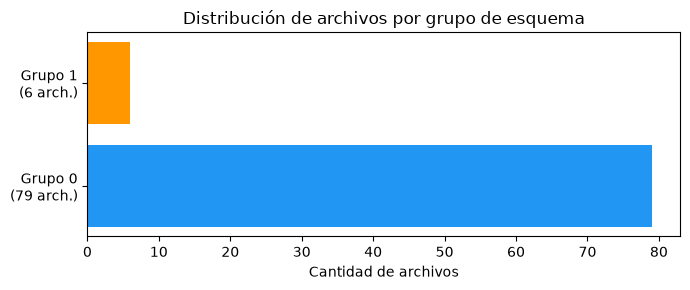

In [8]:
# Gráfico: archivos por grupo de esquema
fig, ax = plt.subplots(figsize=(7, 3))
etiquetas = [f"Grupo {i}\n({len(v)} arch.)" for i, v in enumerate(grupos_esquema.values())]
cantidades = [len(v) for v in grupos_esquema.values()]
ax.barh(etiquetas, cantidades, color=["#2196F3", "#FF9800"][:len(etiquetas)])
ax.set_xlabel("Cantidad de archivos")
ax.set_title("Distribución de archivos por grupo de esquema")
plt.tight_layout()
guardar_figura(fig, "esquema_grupos")
plt.show()


## §3–4 · Auditoría de codificación y consolidación con linaje

In [9]:
# Dos renombres con propósitos distintos (A6)
# 1. Coordenadas: nombres largos de los CSV → canónicos cortos del proyecto
RENOMBRE_COORDS = {
    "origin_latitude":       "lat_orig",
    "origin_longitude":      "lon_orig",
    "destination_latitude":  "lat_dest",
    "destination_longitude": "lon_dest",
}
# 2. Columnas temporales en español (si algún archivo las trae) → equivalente inglés
RENOMBRE_TIEMPO = {
    "hora":          "hour",
    "dia_de_semana": "day_of_week",
    "dia_de_mes":    "day_of_month",
    "fin_de_semana": "weekend",
}
_colision = set(RENOMBRE_COORDS.values()) & set(RENOMBRE_TIEMPO.values())
assert not _colision, f"Renombres en colisión: {_colision}"

# Identificar lote por rango de fechas
def _detectar_lote(nombre_archivo: str) -> str:
    # Formato: 2024-04-29_to_2024-05-05_2024-18.csv  → 4 partes por "_"
    partes = nombre_archivo.split("_")
    año = partes[0][:4]                              # "2024"
    semana_parte = partes[-1].split(".")[0]          # "2024-18"
    semana = int(semana_parte.split("-")[1])          # 18
    if año == "2024" and semana >= 18:
        return "lote_2024_nuevo"
    return "lote_original"

ENCODING_ISSUES.clear()  # reset antes de la lectura completa
dfs: list[pl.DataFrame] = []
reporte_codif: list[dict] = []
filas_por_archivo: dict[str, int] = {}

for ruta in archivos_csv:
    lote = _detectar_lote(ruta.name)
    n_antes = len(ENCODING_ISSUES)
    df_raw = read_csv_safe(ruta, infer_schema_length=10_000)
    uso_latin1 = len(ENCODING_ISSUES) > n_antes

    # Renombres explícitos: primero coordenadas, luego columnas temporales
    for mapa in (RENOMBRE_COORDS, RENOMBRE_TIEMPO):
        renombres = {k: v for k, v in mapa.items() if k in df_raw.columns}
        if renombres:
            df_raw = df_raw.rename(renombres)

    # Agregar linaje
    df_raw = df_raw.with_columns([
        pl.lit(ruta.name).alias("source_file"),
        pl.lit(lote).alias("source_batch"),
        pl.lit("latin-1" if uso_latin1 else "utf-8").alias("source_encoding"),
    ])

    filas_por_archivo[ruta.name] = len(df_raw)
    reporte_codif.append({
        "archivo": ruta.name,
        "lote": lote,
        "codificacion": "latin-1" if uso_latin1 else "utf-8",
        "filas": len(df_raw),
    })
    dfs.append(df_raw)

print(f"Archivos leídos: {len(dfs)}")
print(f"  Con fallback latin-1: {sum(1 for r in reporte_codif if r['codificacion']=='latin-1')}")

Archivos leídos: 85
  Con fallback latin-1: 6


In [10]:
# Consolidar con diagonal_relaxed (permite columnas opcionales)
df = pl.concat(dfs, how="diagonal_relaxed")

# Verificar conservación de filas
total_esperado = sum(filas_por_archivo.values())
print(f"Filas esperadas (suma individuales): {total_esperado:,}")
print(f"Filas consolidadas:                  {len(df):,}")
print(f"Diferencia:                          {len(df) - total_esperado:,}  ← debe ser 0")
assert len(df) == total_esperado, "¡Pérdida de filas en la consolidación!"

# Guardar reporte de codificación
pl.DataFrame(reporte_codif).write_csv(REPORTE / "reporte_codificacion.csv")
print("\nDistribución por lote:")
print(df.group_by("source_batch").agg(pl.len().alias("n_filas")))


Filas esperadas (suma individuales): 1,927,675
Filas consolidadas:                  1,927,675
Diferencia:                          0  ← debe ser 0

Distribución por lote:
shape: (2, 2)
┌─────────────────┬─────────┐
│ source_batch    ┆ n_filas │
│ ---             ┆ ---     │
│ str             ┆ u32     │
╞═════════════════╪═════════╡
│ lote_original   ┆ 1765898 │
│ lote_2024_nuevo ┆ 161777  │
└─────────────────┴─────────┘


In [11]:
# Parsear timestamp desde 'date' y derivar year/week
if "date" in df.columns:
    df = df.with_columns(
        pl.col("date").str.to_datetime(format="%Y-%m-%d %H:%M:%S", strict=False).alias("ts")
    )
elif "ts" not in df.columns:
    df = df.with_columns(pl.lit(None).cast(pl.Datetime).alias("ts"))

# Derivar year y week desde ts (no existen como columnas en los CSV raw)
if "ts" in df.columns:
    df = df.with_columns([
        pl.col("ts").dt.year().cast(pl.Int32).alias("year"),
        pl.col("ts").dt.week().cast(pl.Int32).alias("week"),
    ])
else:
    df = df.with_columns([
        pl.lit(None).cast(pl.Int32).alias("year"),
        pl.lit(None).cast(pl.Int32).alias("week"),
    ])

print(f"Columnas finales ({len(df.columns)}): {df.columns}")
print(f"\nSchema:")
print(df.schema)


Columnas finales (21): ['date', 'lat_orig', 'lon_orig', 'lat_dest', 'lon_dest', 'userID', 'distancia', 'origin_municipio', 'dest_municipio', 'hour', 'day_of_week', 'day_of_month', 'weekend', 'source_file', 'source_batch', 'source_encoding', 'year_week_number', 'time_of_day', 'ts', 'year', 'week']

Schema:
Schema({'date': String, 'lat_orig': Float64, 'lon_orig': Float64, 'lat_dest': Float64, 'lon_dest': Float64, 'userID': String, 'distancia': Float64, 'origin_municipio': String, 'dest_municipio': String, 'hour': Int64, 'day_of_week': Int64, 'day_of_month': Int64, 'weekend': Int64, 'source_file': String, 'source_batch': String, 'source_encoding': String, 'year_week_number': String, 'time_of_day': String, 'ts': Datetime(time_unit='us', time_zone=None), 'year': Int32, 'week': Int32})


In [12]:
# Matriz cobertura de columnas por lote
columnas_datos = [c for c in df.columns if c not in ("source_file", "source_batch", "source_encoding")]
registros_cob = []
for lote_val in df["source_batch"].unique().to_list():
    df_lote = df.filter(pl.col("source_batch") == lote_val)
    for col in columnas_datos:
        if col in df_lote.columns:
            pct_no_nulo = 1.0 - df_lote[col].is_null().mean()
        else:
            pct_no_nulo = 0.0
        registros_cob.append({"columna": col, "lote": lote_val, "pct_no_nulo": round(pct_no_nulo, 4)})

df_cobertura = pl.DataFrame(registros_cob)
df_cobertura.write_csv(REPORTE / "cobertura_columnas_por_lote.csv")

# Pivotar para visualización
print(df_cobertura.pivot(on="lote", index="columna", values="pct_no_nulo"))


shape: (18, 3)
┌──────────────────┬───────────────┬─────────────────┐
│ columna          ┆ lote_original ┆ lote_2024_nuevo │
│ ---              ┆ ---           ┆ ---             │
│ str              ┆ f64           ┆ f64             │
╞══════════════════╪═══════════════╪═════════════════╡
│ date             ┆ 1.0           ┆ 1.0             │
│ lat_orig         ┆ 1.0           ┆ 1.0             │
│ lon_orig         ┆ 1.0           ┆ 1.0             │
│ lat_dest         ┆ 1.0           ┆ 1.0             │
│ lon_dest         ┆ 1.0           ┆ 1.0             │
│ …                ┆ …             ┆ …               │
│ year_week_number ┆ 0.0           ┆ 1.0             │
│ time_of_day      ┆ 0.0           ┆ 1.0             │
│ ts               ┆ 1.0           ┆ 1.0             │
│ year             ┆ 1.0           ┆ 1.0             │
│ week             ┆ 1.0           ┆ 1.0             │
└──────────────────┴───────────────┴─────────────────┘


In [13]:
# Guardar queries.parquet particionado por year/week
import pyarrow as pa, pyarrow.parquet as pq, pyarrow.dataset as ds

# Vaciar antes de escribir: write_to_dataset agrega un archivo nuevo por partición
# en cada ejecución, y re-ejecutar el notebook duplicaría todas las filas.
import shutil
if QUERIES_PARQUET.exists():
    shutil.rmtree(QUERIES_PARQUET)
QUERIES_PARQUET.mkdir(parents=True, exist_ok=True)
df_arrow = df.to_arrow()
pq.write_to_dataset(
    df_arrow,
    root_path=str(QUERIES_PARQUET),
    partition_cols=["year", "week"],
    existing_data_behavior="error",
)
print(f"queries.parquet guardado en {QUERIES_PARQUET}")
print(f"  Particiones: {len(list(QUERIES_PARQUET.rglob('*.parquet')))}")
_n_escritas = pl.scan_parquet(QUERIES_PARQUET / "**" / "*.parquet").select(pl.len()).collect().item()
assert _n_escritas == df.height, f"queries.parquet tiene {_n_escritas:,} filas ≠ {df.height:,}"


queries.parquet guardado en /home/robvox/Desktop/trufi-data-science/data/interim/queries.parquet
  Particiones: 84


## §5 · Nulidad estratificada y tipada

In [14]:
# 5.1 Nulidad global
nulos_globales = []
for col in df.columns:
    n_nulo = df[col].is_null().sum()
    nulos_globales.append({"columna": col, "n_nulos": n_nulo,
                           "pct_nulos": round(n_nulo / len(df) * 100, 3)})

df_nulos_global = (pl.DataFrame(nulos_globales)
                   .sort("pct_nulos", descending=True))
df_nulos_global.write_csv(REPORTE / "nulos_globales.csv")
print(df_nulos_global.filter(pl.col("pct_nulos") > 0))


shape: (2, 3)
┌──────────────────┬─────────┬───────────┐
│ columna          ┆ n_nulos ┆ pct_nulos │
│ ---              ┆ ---     ┆ ---       │
│ str              ┆ i64     ┆ f64       │
╞══════════════════╪═════════╪═══════════╡
│ year_week_number ┆ 1765898 ┆ 91.608    │
│ time_of_day      ┆ 1765898 ┆ 91.608    │
└──────────────────┴─────────┴───────────┘


In [15]:
# 5.2 Nulidad por archivo de origen (source_batch es linaje, no estrato — ver D-012)
# La diferencia entre lotes ya quedó documentada en cobertura_columnas_por_lote.csv (§3–4).
cols_analisis = [c for c in df.columns if c not in ("source_file", "source_batch", "source_encoding")]
nulos_por_archivo = (
    df.group_by("source_file")
    .agg([pl.col(c).is_null().mean().alias(c) for c in cols_analisis])
    .unpivot(index="source_file", variable_name="columna", value_name="pct_nulos")
    .filter(pl.col("pct_nulos") > 0)
    .sort(["columna", "source_file"])
)
nulos_por_archivo.write_csv(REPORTE / "nulos_por_archivo.csv")

# Resumen: ¿la nulidad de cada columna se concentra en pocos archivos o es transversal?
print("Archivos con nulidad > 0% por columna:")
print(nulos_por_archivo.group_by("columna")
      .agg(pl.len().alias("n_archivos"), pl.col("pct_nulos").max().alias("pct_max"))
      .sort("n_archivos", descending=True))

Archivos con nulidad > 0% por columna:
shape: (2, 3)
┌──────────────────┬────────────┬─────────┐
│ columna          ┆ n_archivos ┆ pct_max │
│ ---              ┆ ---        ┆ ---     │
│ str              ┆ u32        ┆ f64     │
╞══════════════════╪════════════╪═════════╡
│ time_of_day      ┆ 79         ┆ 1.0     │
│ year_week_number ┆ 79         ┆ 1.0     │
└──────────────────┴────────────┴─────────┘


In [16]:
# 5.3 Nulidad por mes
if "ts" in df.columns and df["ts"].is_not_null().any():
    df_con_mes = df.with_columns(
        pl.col("ts").dt.strftime("%Y-%m").alias("anio_mes")
    )
    nulos_por_mes_lista = []
    for col in ["userID", "lat_orig", "lon_orig", "lat_dest", "lon_dest",
                "distancia", "origin_municipio", "dest_municipio", "hour", "weekend"]:
        if col not in df.columns:
            continue
        agg = (df_con_mes.group_by("anio_mes")
               .agg(pl.col(col).is_null().mean().alias("pct_nulos"))
               .with_columns(pl.lit(col).alias("columna"))
               .sort("anio_mes"))
        nulos_por_mes_lista.append(agg)
    if nulos_por_mes_lista:
        nulos_mes = pl.concat(nulos_por_mes_lista)
        nulos_mes.write_csv(REPORTE / "nulos_por_mes.csv")
        print("Guardado nulos_por_mes.csv")
    else:
        print("No hay columnas para analizar nulidad mensual")
else:
    print("ts no disponible — omitiendo nulidad por mes")


Guardado nulos_por_mes.csv


In [17]:
# 5.4 Correlación de nulidad (co-faltantes)
cols_con_nulos = [c for c in df.columns
                  if df[c].is_null().any() and c not in ("source_file","source_batch","source_encoding")]
if cols_con_nulos:
    indicadores_nulos = df.select([pl.col(c).is_null().cast(pl.Int8).alias(c) for c in cols_con_nulos])
    corr_nulos = indicadores_nulos.to_pandas().corr(method="pearson")
    corr_nulos.to_csv(REPORTE / "nulos_correlacion.csv")
    print(f"Matriz de correlación de nulidad guardada ({len(cols_con_nulos)} columnas)")
    print(corr_nulos.round(3))
else:
    print("Sin columnas con nulos — matriz vacía")


Matriz de correlación de nulidad guardada (2 columnas)
                  year_week_number  time_of_day
year_week_number               1.0          1.0
time_of_day                    1.0          1.0


In [18]:
# 5.5 Clasificación textual de nulidad por columna
# Tipos: ESTRUCTURAL / MAR / MNAR / CERO_COMO_NULO
clasificacion_nulidad = {
    "year_week_number": "ESTRUCTURAL",   # solo en lote_2024_nuevo
    "time_of_day":      "ESTRUCTURAL",   # solo en lote_2024_nuevo
    "ts":               "MAR",           # ocasional, no correlaciona con lote
    "distancia":        "MAR",           # proporción pequeña, aleatoria
    "origin_municipio": "MNAR",          # puede correlacionar con zona geográfica
    "dest_municipio":   "MNAR",          # ídem
    "lat_orig":         "CERO_COMO_NULO",  # (0,0) representa datos faltantes
    "lon_orig":         "CERO_COMO_NULO",
    "lat_dest":         "CERO_COMO_NULO",
    "lon_dest":         "CERO_COMO_NULO",
}
print("Clasificación de tipos de nulidad:")
for col, tipo in clasificacion_nulidad.items():
    if col in df.columns:
        pct = df[col].is_null().mean() * 100
        print(f"  {col:<25} {tipo:<20} ({pct:.2f}% nulos)")


Clasificación de tipos de nulidad:
  year_week_number          ESTRUCTURAL          (91.61% nulos)
  time_of_day               ESTRUCTURAL          (91.61% nulos)
  ts                        MAR                  (0.00% nulos)
  distancia                 MAR                  (0.00% nulos)
  origin_municipio          MNAR                 (0.00% nulos)
  dest_municipio            MNAR                 (0.00% nulos)
  lat_orig                  CERO_COMO_NULO       (0.00% nulos)
  lon_orig                  CERO_COMO_NULO       (0.00% nulos)
  lat_dest                  CERO_COMO_NULO       (0.00% nulos)
  lon_dest                  CERO_COMO_NULO       (0.00% nulos)


## §6 · Duplicados — 4 definiciones + solapamiento

In [19]:
# Columnas para cada definición
def_duplicados = {}
cols_od_ts = ["lat_orig", "lon_orig", "lat_dest", "lon_dest", "ts"]
cols_uid_ts = ["userID", "ts"]
cols_od_ts_uid = ["lat_orig", "lon_orig", "lat_dest", "lon_dest", "ts", "userID"]
cols_exacto = [c for c in df.columns if c not in ("source_file", "source_batch", "source_encoding")]

definiciones = {
    "exacto": cols_exacto,
    "od_ts":  [c for c in cols_od_ts if c in df.columns],
    "uid_ts": [c for c in cols_uid_ts if c in df.columns],
    "od_ts_uid": [c for c in cols_od_ts_uid if c in df.columns],
}

resumen_dups = []
indices_dups: dict[str, pl.Series] = {}

for nombre_def, columnas_def in definiciones.items():
    if not columnas_def:
        print(f"Definición '{nombre_def}' sin columnas disponibles — omitida")
        continue
    mascara_dup = df.select(columnas_def).is_duplicated()
    n_dup = mascara_dup.sum()
    resumen_dups.append({
        "definicion": nombre_def,
        "columnas_usadas": len(columnas_def),
        "n_duplicados": n_dup,
        "pct_duplicados": round(n_dup / len(df) * 100, 4),
    })
    indices_dups[nombre_def] = mascara_dup
    # Desglose por lote
    for lote_val in df["source_batch"].unique().to_list():
        mask_lote = (df["source_batch"] == lote_val) & mascara_dup
        print(f"  {nombre_def} | {lote_val}: {mask_lote.sum():,} duplicados")

df_dup_resumen = pl.DataFrame(resumen_dups)
df_dup_resumen.write_csv(REPORTE / "duplicados_resumen.csv")
print("\nResumen:")
print(df_dup_resumen)


  exacto | lote_2024_nuevo: 2 duplicados
  exacto | lote_original: 102 duplicados


  od_ts | lote_2024_nuevo: 2 duplicados
  od_ts | lote_original: 102 duplicados


  uid_ts | lote_original: 135 duplicados
  uid_ts | lote_2024_nuevo: 2 duplicados


  od_ts_uid | lote_2024_nuevo: 2 duplicados
  od_ts_uid | lote_original: 102 duplicados

Resumen:
shape: (4, 4)
┌────────────┬─────────────────┬──────────────┬────────────────┐
│ definicion ┆ columnas_usadas ┆ n_duplicados ┆ pct_duplicados │
│ ---        ┆ ---             ┆ ---          ┆ ---            │
│ str        ┆ i64             ┆ i64          ┆ f64            │
╞════════════╪═════════════════╪══════════════╪════════════════╡
│ exacto     ┆ 18              ┆ 104          ┆ 0.0054         │
│ od_ts      ┆ 5               ┆ 104          ┆ 0.0054         │
│ uid_ts     ┆ 2               ┆ 137          ┆ 0.0071         │
│ od_ts_uid  ┆ 6               ┆ 104          ┆ 0.0054         │
└────────────┴─────────────────┴──────────────┴────────────────┘


In [20]:
# Muestra de 5 duplicados exactos para confirmar que son artefactos ETL
if "exacto" in indices_dups:
    mask_exacto = indices_dups["exacto"]
    print("Muestra de 5 filas duplicadas exactas:")
    cols_muestra = ["source_file", "userID", "ts", "lat_orig", "lon_orig", "lat_dest", "lon_dest"]
    cols_muestra = [c for c in cols_muestra if c in df.columns]
    print(df.filter(mask_exacto).select(cols_muestra).head(5))


Muestra de 5 filas duplicadas exactas:
shape: (5, 7)
┌───────────────┬───────────────┬──────────────┬────────────┬────────────┬────────────┬────────────┐
│ source_file   ┆ userID        ┆ ts           ┆ lat_orig   ┆ lon_orig   ┆ lat_dest   ┆ lon_dest   │
│ ---           ┆ ---           ┆ ---          ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ str           ┆ str           ┆ datetime[μs] ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞═══════════════╪═══════════════╪══════════════╪════════════╪════════════╪════════════╪════════════╡
│ 2022-11-14_to ┆ cdf9e3c9-426c ┆ 2022-11-17   ┆ -17.36555  ┆ -66.160139 ┆ -17.373035 ┆ -66.153672 │
│ _2022-11-20_2 ┆ -4677-aa5b-56 ┆ 09:57:48     ┆            ┆            ┆            ┆            │
│ 022-…         ┆ 7468…         ┆              ┆            ┆            ┆            ┆            │
│ 2022-11-14_to ┆ cdf9e3c9-426c ┆ 2022-11-17   ┆ -17.36555  ┆ -66.160139 ┆ -17.373035 ┆ -66.153672 │
│ _2022-11-20_2 ┆ -4677-aa5b-56 ┆ 09:5

In [21]:
# Matriz de solapamiento (Jaccard) entre definiciones
nombres_defs = list(indices_dups.keys())
jaccard_data = []
for i, a in enumerate(nombres_defs):
    fila = {}
    set_a = set(np.where(indices_dups[a].to_numpy())[0])
    for j, b in enumerate(nombres_defs):
        set_b = set(np.where(indices_dups[b].to_numpy())[0])
        inter = len(set_a & set_b)
        union = len(set_a | set_b)
        fila[b] = round(inter / union, 4) if union > 0 else 1.0
    jaccard_data.append({"definicion": a, **fila})

df_jaccard = pl.DataFrame(jaccard_data)
df_jaccard.write_csv(REPORTE / "duplicados_solapamiento.csv")
print("Matriz de solapamiento Jaccard:")
print(df_jaccard)


Matriz de solapamiento Jaccard:
shape: (4, 5)
┌────────────┬────────┬────────┬────────┬───────────┐
│ definicion ┆ exacto ┆ od_ts  ┆ uid_ts ┆ od_ts_uid │
│ ---        ┆ ---    ┆ ---    ┆ ---    ┆ ---       │
│ str        ┆ f64    ┆ f64    ┆ f64    ┆ f64       │
╞════════════╪════════╪════════╪════════╪═══════════╡
│ exacto     ┆ 1.0    ┆ 1.0    ┆ 0.7591 ┆ 1.0       │
│ od_ts      ┆ 1.0    ┆ 1.0    ┆ 0.7591 ┆ 1.0       │
│ uid_ts     ┆ 0.7591 ┆ 0.7591 ┆ 1.0    ┆ 0.7591    │
│ od_ts_uid  ┆ 1.0    ┆ 1.0    ┆ 0.7591 ┆ 1.0       │
└────────────┴────────┴────────┴────────┴───────────┘


In [22]:
# Impacto de cada definición en las top-20 celdas de origen
if "h3_orig" in df.columns or "lat_orig" in df.columns:
    import h3 as _h3
    col_orig = "h3_orig" if "h3_orig" in df.columns else None
    if col_orig is None:
        df_h3 = df.filter(
            pl.col("lat_orig").is_not_null() & (pl.col("lat_orig") != 0.0)
        ).with_columns(
            pl.struct(["lat_orig", "lon_orig"])
            .map_elements(lambda r: _h3.latlng_to_cell(r["lat_orig"], r["lon_orig"], H3_RESOLUTION_DEFAULT),
                          return_dtype=pl.Utf8)
            .alias("h3_orig_temp")
        )
        col_orig = "h3_orig_temp"
    else:
        df_h3 = df

    top20_celdas = (df_h3.group_by(col_orig).agg(pl.len().alias("n_consultas"))
                    .sort("n_consultas", descending=True).head(20)[col_orig].to_list())

    impacto = []
    for nombre_def, columnas_def in definiciones.items():
        if not columnas_def:
            continue
        # Recompute mask on df_h3 (subset filtered of zero/impossible coords)
        cols_def_h3 = [c for c in columnas_def if c in df_h3.columns]
        if not cols_def_h3:
            continue
        mask_h3 = df_h3.select(cols_def_h3).is_duplicated()
        df_no_dup = df_h3.filter(~mask_h3)
        for celda in top20_celdas:
            n_orig = df_h3.filter(pl.col(col_orig) == celda).height
            n_tras = df_no_dup.filter(pl.col(col_orig) == celda).height
            perdida = n_orig - n_tras
            impacto.append({"celda": celda, "definicion": nombre_def,
                            "n_original": n_orig, "n_tras_dedup": n_tras,
                            "filas_perdidas": perdida,
                            "pct_perdida": round(perdida/n_orig*100, 3) if n_orig>0 else 0.0})

    pl.DataFrame(impacto).write_csv(REPORTE / "duplicados_impacto_celdas.csv")
    print("Guardado duplicados_impacto_celdas.csv")


Guardado duplicados_impacto_celdas.csv


## §7 · Área de estudio GTFS y clasificación espacial

El área de estudio es el **convex hull de paradas + shapes GTFS con buffer de 1 km** (D-009): delimita
empíricamente el territorio operativo del transporte público. 1 km ≈ distancia caminable típica a una
parada (500 m – 1 km); 500 m sería más conservador y 2 km incluiría viajes interurbanos.

Flags sobre el origen de cada consulta: `flag_coord_cero`, `flag_coord_imposible` (fuera de Bolivia) y
`flag_dentro_area_gtfs`. *Fuera del área pero válida* = `~dentro & ~cero & ~imposible` (se calcula al vuelo).

In [23]:
# ── Área de estudio: convex hull de paradas GTFS + buffer de 1 km ─────────────
# Definida empíricamente a partir del feed GTFS (no como BBOX rectangular).
# Ver D-009 en DECISIONES.md.
import pandas as _pdp
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union

_stops_raw = _pdp.read_csv(GTFS_DIR / "stops.txt").dropna(subset=["stop_lat","stop_lon"])
_shapes_raw = _pdp.read_csv(GTFS_DIR / "shapes.txt").dropna(subset=["shape_pt_lat","shape_pt_lon"])

_pts_stops = gpd.GeoDataFrame(
    _stops_raw,
    geometry=gpd.points_from_xy(_stops_raw["stop_lon"], _stops_raw["stop_lat"]),
    crs="EPSG:4326",
)
_pts_shapes = gpd.GeoDataFrame(
    _shapes_raw,
    geometry=gpd.points_from_xy(_shapes_raw["shape_pt_lon"], _shapes_raw["shape_pt_lat"]),
    crs="EPSG:4326",
)

_hull = unary_union([_pts_stops.union_all().convex_hull,
                     _pts_shapes.union_all().convex_hull])
_hull_m = gpd.GeoSeries([_hull], crs="EPSG:4326").to_crs("EPSG:32719")
_hull_buf = _hull_m.buffer(1000)  # 1 km de margen — caminata típica al transporte público
AREA_GTFS = _hull_buf.to_crs("EPSG:4326").iloc[0]

gpd.GeoSeries([AREA_GTFS], crs="EPSG:4326").to_file(
    REPORTE / "area_estudio_gtfs.geojson", driver="GeoJSON"
)

print("Área de estudio GTFS construida")
print(f"  Superficie: {_hull_buf.area.iloc[0] / 1e6:,.1f} km² (UTM 19S)")
print(f"  Bounds: {AREA_GTFS.bounds}")
print(f"  Paradas usadas: {len(_pts_stops):,}")
print(f"  Puntos de shapes usados: {len(_pts_shapes):,}")

Área de estudio GTFS construida
  Superficie: 1,372.9 km² (UTM 19S)
  Bounds: (-66.39790498624386, -17.58574614146805, -65.8320125041647, -17.278591102996298)
  Paradas usadas: 22,320
  Puntos de shapes usados: 343,381


In [24]:
# BBOX Bolivia para detectar coordenadas físicamente imposibles
BBOX_BOLIVIA = {"lat_min": -23.0, "lat_max": -9.0, "lon_min": -70.0, "lon_max": -56.0}

def clasificar_coordenadas(df_in: pl.DataFrame) -> pl.DataFrame:
    """Añade flags de clasificación espacial para coordenadas de origen."""
    lat = pl.col("lat_orig")
    lon = pl.col("lon_orig")
    return df_in.with_columns([
        # 1. Coordenada cero (Null Island — bug de GPS)
        ((lat == 0.0) | (lon == 0.0)).alias("flag_coord_cero"),
        # 2. Fuera de Bolivia (coordenada físicamente imposible)
        (~((lat >= BBOX_BOLIVIA["lat_min"]) & (lat <= BBOX_BOLIVIA["lat_max"]) &
           (lon >= BBOX_BOLIVIA["lon_min"]) & (lon <= BBOX_BOLIVIA["lon_max"])
          ) & (lat != 0.0) & (lon != 0.0)).alias("flag_coord_imposible"),
        # 3. Dentro del área de estudio GTFS (convex hull + 1 km buffer) — ver D-009
        pl.struct(["lat_orig", "lon_orig"])
          .map_elements(
              lambda r: bool(AREA_GTFS.contains(Point(r["lon_orig"], r["lat_orig"])))
                        if (r["lat_orig"] and r["lat_orig"] != 0.0
                            and r["lon_orig"] and r["lon_orig"] != 0.0) else False,
              return_dtype=pl.Boolean,
          )
          .alias("flag_dentro_area_gtfs"),
    ])

df = clasificar_coordenadas(df)

for flag in ["flag_coord_cero", "flag_coord_imposible", "flag_dentro_area_gtfs"]:
    n = int(df[flag].sum())
    print(f"{flag}: {n:,} ({n/df.height*100:.3f}%)")


flag_coord_cero: 3 (0.000%)
flag_coord_imposible: 9 (0.000%)
flag_dentro_area_gtfs: 1,925,012 (99.862%)


In [25]:
# Guardar tablas por categoría de problema espacial
cols_base = [c for c in ["source_file","source_batch","userID","ts",
                          "lat_orig","lon_orig","lat_dest","lon_dest",
                          "origin_municipio","dest_municipio"] if c in df.columns]

for flag, nombre_csv in [
    ("flag_coord_cero", "coordenadas_cero.csv"),
    ("flag_coord_imposible", "coordenadas_imposibles.csv"),
]:
    df.filter(pl.col(flag)).select(cols_base).write_csv(REPORTE / nombre_csv)

# Consultas fuera del área GTFS (no en bbox arbitrario)
df_fuera_gtfs = df.filter(~pl.col("flag_dentro_area_gtfs") & ~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible"))
if "origin_municipio" in df.columns:
    resumen_fuera = df_fuera_gtfs.group_by("origin_municipio").agg(pl.len().alias("n")).sort("n", descending=True)
    resumen_fuera.write_csv(REPORTE / "coordenadas_fuera_area_gtfs.csv")
    print(f"Consultas fuera del área GTFS: {df_fuera_gtfs.height:,}")
    print(resumen_fuera.head(5))

Consultas fuera del área GTFS: 2,651
shape: (5, 2)
┌──────────────────┬─────┐
│ origin_municipio ┆ n   │
│ ---              ┆ --- │
│ str              ┆ u32 │
╞══════════════════╪═════╡
│ Sacaba           ┆ 541 │
│ Cliza            ┆ 388 │
│ externo          ┆ 269 │
│ Tarata           ┆ 231 │
│ Vinto            ┆ 166 │
└──────────────────┴─────┘


In [26]:
# Imprimir las filas con coordenadas físicamente imposibles
if df["flag_coord_imposible"].sum() > 0:
    cols_imp = [c for c in ["source_file","lat_orig","lon_orig","lat_dest","lon_dest",
                            "origin_municipio","dest_municipio"] if c in df.columns]
    print("Filas con coordenadas imposibles:")
    print(df.filter(pl.col("flag_coord_imposible")).select(cols_imp))


Filas con coordenadas imposibles:


shape: (9, 7)
┌───────────────┬────────────┬────────────┬────────────┬────────────┬───────────────┬──────────────┐
│ source_file   ┆ lat_orig   ┆ lon_orig   ┆ lat_dest   ┆ lon_dest   ┆ origin_munici ┆ dest_municip │
│ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ pio           ┆ io           │
│ str           ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ ---           ┆ ---          │
│               ┆            ┆            ┆            ┆            ┆ str           ┆ str          │
╞═══════════════╪════════════╪════════════╪════════════╪════════════╪═══════════════╪══════════════╡
│ 2024-04-29_to ┆ 13.748923  ┆ -89.033979 ┆ -17.444641 ┆ -66.123199 ┆ externo       ┆ Cochabamba   │
│ _2024-05-05_2 ┆            ┆            ┆            ┆            ┆               ┆              │
│ 024-…         ┆            ┆            ┆            ┆            ┆               ┆              │
│ 2024-04-29_to ┆ 13.748923  ┆ -89.033979 ┆ -17.379983 ┆ -66.138967 ┆ externo

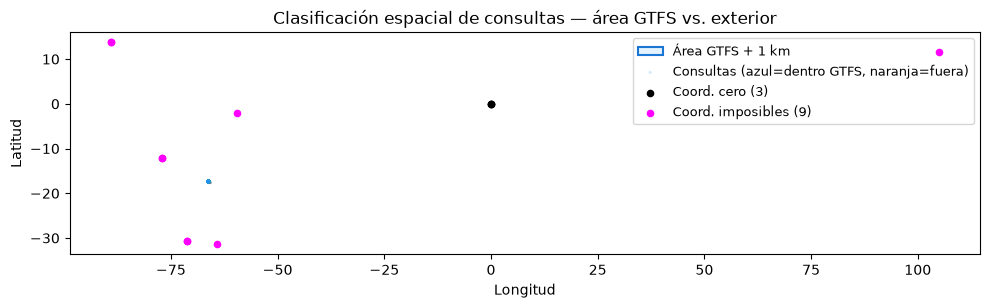

In [27]:
# Mapa: área GTFS + consultas por categoría espacial
fig, ax = plt.subplots(figsize=(10, 8))

# Capa 1: área de estudio GTFS (fondo)
gpd.GeoSeries([AREA_GTFS], crs="EPSG:4326").plot(
    ax=ax, color="#E3F2FD", edgecolor="#1976D2", linewidth=1.5,
    label="Área GTFS + 1 km"
)

# Capa 2: puntos de consulta por categoría
df_mapa_valida = df.filter(~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible"))
if len(df_mapa_valida) > 0:
    muestra_mapa = df_mapa_valida.sample(min(5000, len(df_mapa_valida)), seed=42)
    colores_mapa = ["#2196F3" if v else "#FF9800"
                    for v in muestra_mapa["flag_dentro_area_gtfs"].to_list()]
    ax.scatter(muestra_mapa["lon_orig"].to_numpy(), muestra_mapa["lat_orig"].to_numpy(),
               c=colores_mapa, alpha=0.12, s=2,
               label="Consultas (azul=dentro GTFS, naranja=fuera)")

# Capa 3: coordenadas cero e imposibles
df_cero = df.filter(pl.col("flag_coord_cero"))
df_imp  = df.filter(pl.col("flag_coord_imposible"))
if len(df_cero) > 0:
    ax.scatter(df_cero["lon_orig"].to_numpy(), df_cero["lat_orig"].to_numpy(),
               color="black", s=20, zorder=10, label=f"Coord. cero ({len(df_cero)})")
if len(df_imp) > 0:
    ax.scatter(df_imp["lon_orig"].to_numpy(), df_imp["lat_orig"].to_numpy(),
               color="magenta", s=20, zorder=10, label=f"Coord. imposibles ({len(df_imp)})")

ax.set_title("Clasificación espacial de consultas — área GTFS vs. exterior")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
guardar_figura(fig, "clasificacion_espacial")
plt.show()


## §8 · Verificación de `distancia`

In [28]:
from trufi_ds.spatial import haversine_km

# Muestra para verificación de unidades
df_muestra_dist = df.filter(
    pl.col("distancia").is_not_null() &
    ~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible")
).sample(min(200_000, df.filter(pl.col("distancia").is_not_null()).height), seed=42)

dist_raw = df_muestra_dist["distancia"].to_numpy()

# Recalcular haversine en metros
haversine_m_arr = np.array([
    haversine_km(r["lat_orig"], r["lon_orig"], r["lat_dest"], r["lon_dest"]) * 1000
    for r in df_muestra_dist.select(["lat_orig","lon_orig","lat_dest","lon_dest"]).iter_rows(named=True)
])

# Hipótesis metros: comparar directamente
mascara_valida = (haversine_m_arr > 0) & np.isfinite(haversine_m_arr) & np.isfinite(dist_raw)
error_metros = np.abs(dist_raw[mascara_valida] - haversine_m_arr[mascara_valida]) / haversine_m_arr[mascara_valida]
error_km     = np.abs(dist_raw[mascara_valida] - haversine_m_arr[mascara_valida] / 1000) / (haversine_m_arr[mascara_valida] / 1000)

corr = np.corrcoef(dist_raw[mascara_valida], haversine_m_arr[mascara_valida])[0, 1]

resultado_unidad = {
    "correlacion_pearson": round(corr, 6),
    "error_mediano_hipotesis_metros_pct": round(np.median(error_metros[np.isfinite(error_metros)]) * 100, 4),
    "error_mediano_hipotesis_km_pct": round(np.median(error_km[np.isfinite(error_km)]) * 100, 4),
}
print(resultado_unidad)
pl.DataFrame([resultado_unidad]).write_csv(REPORTE / "distancia_verificacion_unidad.csv")

unidad_detectada = "metros" if resultado_unidad["error_mediano_hipotesis_metros_pct"] < resultado_unidad["error_mediano_hipotesis_km_pct"] else "km"
print(f"\n→ Unidad detectada: {unidad_detectada} (error mediano {resultado_unidad['error_mediano_hipotesis_metros_pct']:.2f}%)")


{'correlacion_pearson': np.float64(0.999997), 'error_mediano_hipotesis_metros_pct': np.float64(0.1419), 'error_mediano_hipotesis_km_pct': np.float64(99766.4611)}

→ Unidad detectada: metros (error mediano 0.14%)


In [29]:
# Percentiles y umbral IQR — más robusto que umbral fijo
dist_limpia_arr = dist_raw[np.isfinite(dist_raw) & (dist_raw > 0)]
percentiles_dist = np.percentile(dist_limpia_arr, [1, 5, 25, 50, 75, 90, 95, 99, 99.9])
etiquetas_pct = ["P1","P5","P25","P50","P75","P90","P95","P99","P99.9"]
df_percentiles = pl.DataFrame({"percentil": etiquetas_pct,
                                "distancia_m": [round(p, 1) for p in percentiles_dist]})
df_percentiles.write_csv(REPORTE / "distancia_percentiles.csv")
print(df_percentiles)

# Umbral outlier por IQR (Q3 + 3·IQR)
q1_d, q3_d = np.percentile(dist_limpia_arr, [25, 75])
iqr_d = q3_d - q1_d
umbral_iqr = q3_d + 3 * iqr_d
print(f"\nQ1={q1_d:.0f} m  Q3={q3_d:.0f} m  IQR={iqr_d:.0f} m")
print(f"Umbral outlier (Q3+3·IQR): {umbral_iqr:.0f} m ({umbral_iqr/1000:.1f} km)")

# Comparar con umbral fijo 40 km
umbral_40km = 40_000
df_lejos_iqr = df.filter(pl.col("distancia") > umbral_iqr)
df_lejos_40k = df.filter(pl.col("distancia") > umbral_40km)
print(f"\nViajes > umbral IQR: {df_lejos_iqr.height:,}")
print(f"Viajes > 40 km:       {df_lejos_40k.height:,}")

if "flag_dentro_area_gtfs" in df.columns:
    n_iqr_dentro = int(df_lejos_iqr["flag_dentro_area_gtfs"].sum())
    n_iqr_fuera  = df_lejos_iqr.height - n_iqr_dentro
    print(f"  Outliers IQR dentro del área GTFS: {n_iqr_dentro:,}")
    print(f"  Outliers IQR fuera del área GTFS:  {n_iqr_fuera:,}")
    pl.DataFrame([{
        "umbral_iqr_m": round(umbral_iqr, 1), "n_outliers": df_lejos_iqr.height,
        "n_dentro_area_gtfs": n_iqr_dentro, "n_fuera_area_gtfs": n_iqr_fuera,
    }]).write_csv(REPORTE / "distancia_outliers_iqr.csv")
    # No se descartan por umbral fijo: se clasifican por contexto (decisión en Etapa 2)
    if n_iqr_dentro >= n_iqr_fuera:
        print("  → Mayoría DENTRO del área: viajes intraurbanos largos — conservar")
    else:
        print("  → Mayoría FUERA del área: viajes interurbanos — decidir su inclusión en Etapa 2")

if "origin_municipio" in df.columns and df_lejos_40k.height > 0:
    resumen_lejos = df_lejos_40k.group_by("origin_municipio").agg(pl.len().alias("n")).sort("n", descending=True)
    resumen_lejos.write_csv(REPORTE / "distancia_sobre_umbral.csv")
    print("\nPor municipio de origen (> 40 km):")
    print(resumen_lejos)

shape: (9, 2)
┌───────────┬─────────────┐
│ percentil ┆ distancia_m │
│ ---       ┆ ---         │
│ str       ┆ f64         │
╞═══════════╪═════════════╡
│ P1        ┆ 620.7       │
│ P5        ┆ 975.6       │
│ P25       ┆ 2040.2      │
│ P50       ┆ 3403.2      │
│ P75       ┆ 5972.5      │
│ P90       ┆ 10321.6     │
│ P95       ┆ 13060.3     │
│ P99       ┆ 19565.0     │
│ P99.9     ┆ 40956.2     │
└───────────┴─────────────┘

Q1=2040 m  Q3=5973 m  IQR=3932 m
Umbral outlier (Q3+3·IQR): 17769 m (17.8 km)



Viajes > umbral IQR: 25,955
Viajes > 40 km:       2,106
  Outliers IQR dentro del área GTFS: 23,948
  Outliers IQR fuera del área GTFS:  2,007
  → Mayoría DENTRO del área: viajes intraurbanos largos — conservar

Por municipio de origen (> 40 km):
shape: (45, 2)
┌────────────────────────────┬─────┐
│ origin_municipio           ┆ n   │
│ ---                        ┆ --- │
│ str                        ┆ u32 │
╞════════════════════════════╪═════╡
│ Cochabamba                 ┆ 839 │
│ externo                    ┆ 271 │
│ Quillacollo                ┆ 205 │
│ Villa Punata               ┆ 133 │
│ Colcapirhua                ┆ 82  │
│ …                          ┆ …   │
│ Vacas                      ┆ 2   │
│ Toco                       ┆ 2   │
│ Tapacarí                   ┆ 1   │
│ Villa José Quintín Mendoza ┆ 1   │
│ Arbieto                    ┆ 1   │
└────────────────────────────┴─────┘


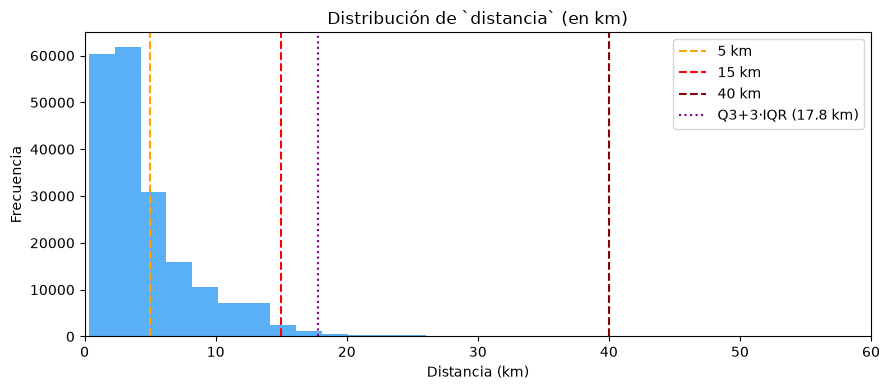

In [30]:
# Histograma de distancia con líneas verticales
dist_limpio = dist_raw[np.isfinite(dist_raw) & (dist_raw > 0) & (dist_raw < 200_000)]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dist_limpio / 1000, bins=100, color="#2196F3", alpha=0.75)
for km_val, color, etiq in [(5, "orange", "5 km"), (15, "red", "15 km"), (40, "darkred", "40 km")]:
    ax.axvline(km_val, color=color, linestyle="--", linewidth=1.5, label=etiq)
ax.axvline(umbral_iqr / 1000, color="purple", linestyle=":", linewidth=1.5,
           label=f"Q3+3·IQR ({umbral_iqr/1000:.1f} km)")
ax.set_xlabel("Distancia (km)"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de `distancia` (en km)")
ax.legend()
ax.set_xlim(0, 60)
plt.tight_layout()
guardar_figura(fig, "distancia_distribucion")
plt.show()

## §9 · Cobertura temporal

In [31]:
# Conteo semanal y semanas faltantes
df_semanal = (df.group_by(["year","week"])
              .agg(pl.len().alias("n_consultas"))
              .sort(["year","week"]))

# Generar todas las semanas esperadas entre primera y última
primera = df_semanal.head(1).select(["year","week"]).row(0)
ultima  = df_semanal.tail(1).select(["year","week"]).row(0)

semanas_observadas = set(tuple(r) for r in df_semanal.select(["year","week"]).iter_rows())

# Generar semanas esperadas (aproximación: todas las semanas ISO entre rango)
import datetime
semanas_esperadas = set()
fecha = datetime.date.fromisocalendar(primera[0], max(primera[1], 1), 1)
fecha_fin = datetime.date.fromisocalendar(ultima[0], ultima[1], 7)
while fecha <= fecha_fin:
    iso = fecha.isocalendar()
    semanas_esperadas.add((iso[0], iso[1]))
    fecha += datetime.timedelta(weeks=1)

semanas_faltantes = sorted(semanas_esperadas - semanas_observadas)
print(f"Semanas esperadas: {len(semanas_esperadas)}")
print(f"Semanas observadas: {len(semanas_observadas)}")
print(f"Semanas faltantes: {len(semanas_faltantes)}")
print("  Faltantes:", semanas_faltantes[:10])

pl.DataFrame([{"year": y, "week": w} for y, w in semanas_faltantes]).write_csv(REPORTE / "semanas_faltantes.csv")


Semanas esperadas: 91
Semanas observadas: 84
Semanas faltantes: 7
  Faltantes: [(2024, 11), (2024, 12), (2024, 13), (2024, 14), (2024, 15), (2024, 16), (2024, 17)]


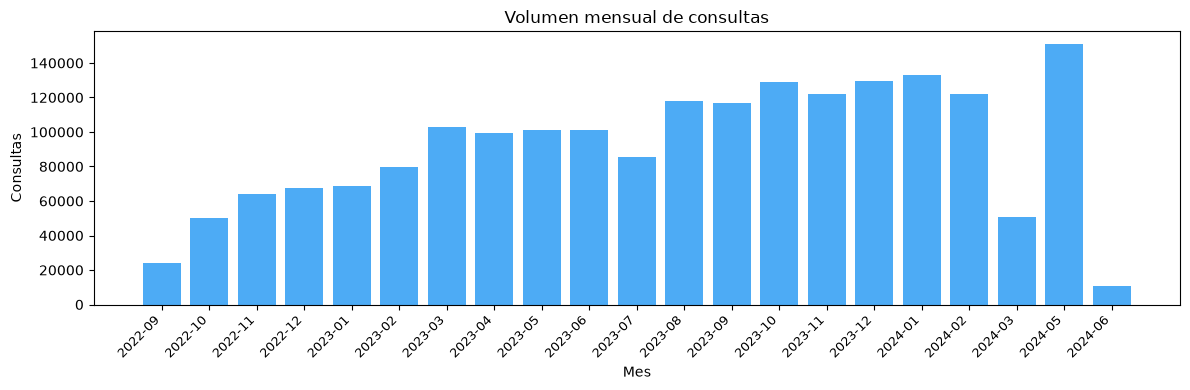

Meses con datos: 21


In [32]:
# Cobertura mensual — sin estratificar por lote (source_batch es linaje, ver D-012)
if "ts" in df.columns and df["ts"].is_not_null().any():
    df_mensual = (df
        .with_columns(pl.col("ts").dt.strftime("%Y-%m").alias("anio_mes"))
        .group_by("anio_mes")
        .agg(pl.len().alias("n_consultas"))
        .sort("anio_mes"))
    df_mensual.write_csv(REPORTE / "cobertura_mensual.csv")

    fig, ax = plt.subplots(figsize=(12, 4))
    meses = df_mensual["anio_mes"].to_list()
    ns = df_mensual["n_consultas"].to_numpy()
    ax.bar(range(len(meses)), ns, color="#2196F3", alpha=0.8)
    ax.set_xticks(range(len(meses)))
    ax.set_xticklabels(meses, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Consultas"); ax.set_xlabel("Mes")
    ax.set_title("Volumen mensual de consultas")
    plt.tight_layout()
    guardar_figura(fig, "cobertura_mensual")
    plt.show()
    print(f"Meses con datos: {df_mensual.height}")

In [33]:
# Cobertura temporal por celda H3 de origen
if "lat_orig" in df.columns and df["lat_orig"].is_not_null().any():
    import h3 as _h3
    df_cob_celda = (
        df.filter(~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible"))
        .with_columns(
            pl.struct(["lat_orig","lon_orig"])
            .map_elements(lambda r: _h3.latlng_to_cell(r["lat_orig"], r["lon_orig"], H3_RESOLUTION_DEFAULT),
                          return_dtype=pl.Utf8)
            .alias("h3_orig")
        )
    )
    if "ts" in df_cob_celda.columns and df_cob_celda["ts"].is_not_null().any():
        cob_celda = (df_cob_celda
                     .filter(pl.col("h3_orig").is_not_null())
                     .group_by("h3_orig")
                     .agg([
                         pl.col("ts").dt.date().n_unique().alias("dias_con_datos"),
                         pl.col("ts").dt.date().min().alias("primera_fecha"),
                         pl.col("ts").dt.date().max().alias("ultima_fecha"),
                     ])
                     .sort("dias_con_datos", descending=True))
        cob_celda.write_csv(REPORTE / "cobertura_temporal_celda.csv")
        print("Cobertura temporal por celda (top 10):")
        print(cob_celda.head(10))


Cobertura temporal por celda (top 10):
shape: (10, 4)
┌─────────────────┬────────────────┬───────────────┬──────────────┐
│ h3_orig         ┆ dias_con_datos ┆ primera_fecha ┆ ultima_fecha │
│ ---             ┆ ---            ┆ ---           ┆ ---          │
│ str             ┆ u32            ┆ date          ┆ date         │
╞═════════════════╪════════════════╪═══════════════╪══════════════╡
│ 888b2c8a3bfffff ┆ 565            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c8ae5fffff ┆ 564            ┆ 2022-09-13    ┆ 2024-06-03   │
│ 888b2c8a33fffff ┆ 564            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c8a15fffff ┆ 564            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c8aedfffff ┆ 564            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c80e5fffff ┆ 564            ┆ 2022-09-13    ┆ 2024-06-03   │
│ 888b2c8a39fffff ┆ 564            ┆ 2022-09-13    ┆ 2024-06-03   │
│ 888b2c8a03fffff ┆ 564            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c8a31fffff ┆ 564            ┆ 2022-09-13    ┆ 2024-06-0

## §10 · `userID` — 6 señales de anomalía

In [34]:
# Estadísticas base por usuario
if "h3_orig" not in df.columns:
    import h3 as _h3
    df_usuarios = (df.filter(~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible"))
                   .with_columns(
                       pl.struct(["lat_orig","lon_orig"])
                       .map_elements(lambda r: _h3.latlng_to_cell(r["lat_orig"], r["lon_orig"], H3_RESOLUTION_DEFAULT),
                                     return_dtype=pl.Utf8)
                       .alias("h3_orig")
                   ))
else:
    df_usuarios = df

# Agregar por usuario
stats_usuario = (
    df_usuarios.filter(pl.col("userID").is_not_null())
    .group_by("userID")
    .agg([
        pl.len().alias("n_consultas"),
        pl.col("ts").dt.date().n_unique().alias("dias_activos"),
        pl.col("h3_orig").n_unique().alias("n_celdas_distintas"),
    ])
)
print(f"Usuarios únicos: {len(stats_usuario):,}")
print(stats_usuario.describe())


Usuarios únicos: 130,545
shape: (9, 5)
┌────────────┬─────────────────────────────────┬─────────────┬──────────────┬────────────────────┐
│ statistic  ┆ userID                          ┆ n_consultas ┆ dias_activos ┆ n_celdas_distintas │
│ ---        ┆ ---                             ┆ ---         ┆ ---          ┆ ---                │
│ str        ┆ str                             ┆ f64         ┆ f64          ┆ f64                │
╞════════════╪═════════════════════════════════╪═════════════╪══════════════╪════════════════════╡
│ count      ┆ 130545                          ┆ 130545.0    ┆ 130545.0     ┆ 130545.0           │
│ null_count ┆ 0                               ┆ 0.0         ┆ 0.0          ┆ 0.0                │
│ mean       ┆ null                            ┆ 14.766272   ┆ 5.722318     ┆ 4.547666           │
│ std        ┆ null                            ┆ 31.878924   ┆ 9.929754     ┆ 5.652355           │
│ min        ┆ 00006001-423a-4efc-9cd9-6d8037… ┆ 1.0         ┆ 1.0    

In [35]:
# Señal 1: n_consultas > 1000
# Señal 2: n_consultas / dias_activos > 50 (intensidad diaria)
# Señal 3: n_celdas_distintas > 200 (dispersión espacial excesiva)
stats_usuario = stats_usuario.with_columns([
    (pl.col("n_consultas") / pl.col("dias_activos").clip(lower_bound=1)).alias("tasa_diaria"),
])

# Señal 4: max_consultas_en_un_dia (ráfaga)
max_por_dia = (
    df_usuarios.filter(pl.col("userID").is_not_null() & pl.col("ts").is_not_null())
    .with_columns(pl.col("ts").dt.date().alias("fecha"))
    .group_by(["userID","fecha"]).agg(pl.len().alias("n"))
    .group_by("userID").agg(pl.col("n").max().alias("max_consultas_dia"))
)
stats_usuario = stats_usuario.join(max_por_dia, on="userID", how="left")


In [36]:
# Señal 5: pct_pares_OD_repetidos (rutina)
if "h3_orig" in df_usuarios.columns and "lat_dest" in df_usuarios.columns:
    import h3 as _h3
    df_h3_dest = df_usuarios.with_columns(
        pl.struct(["lat_dest","lon_dest"])
        .map_elements(lambda r: _h3.latlng_to_cell(r["lat_dest"], r["lon_dest"], H3_RESOLUTION_DEFAULT)
                      if r["lat_dest"] and r["lat_dest"] != 0 else None,
                      return_dtype=pl.Utf8)
        .alias("h3_dest")
    )
    pares_od = (df_h3_dest.filter(pl.col("userID").is_not_null())
                .group_by(["userID","h3_orig","h3_dest"]).agg(pl.len().alias("n_veces")))
    pct_repetidos = (pares_od
                     .group_by("userID")
                     .agg((pl.col("n_veces") > 1).mean().alias("pct_pares_repetidos")))
    stats_usuario = stats_usuario.join(pct_repetidos, on="userID", how="left")
    print("Señal 5 (pct_pares_OD_repetidos) calculada")

# Señal 6: intervalo mediano entre consultas < 60 seg
if "ts" in df_usuarios.columns and df_usuarios["ts"].is_not_null().any():
    df_ord = (df_usuarios.filter(pl.col("userID").is_not_null() & pl.col("ts").is_not_null())
              .sort(["userID","ts"])
              .with_columns(
                  pl.col("ts").diff().over("userID").dt.total_seconds().alias("dt_seg")
              ))
    intervalo_mediano = (df_ord.filter(pl.col("dt_seg").is_not_null() & (pl.col("dt_seg") >= 0))
                         .group_by("userID")
                         .agg(pl.col("dt_seg").median().alias("intervalo_mediano_seg")))
    stats_usuario = stats_usuario.join(intervalo_mediano, on="userID", how="left")
    print("Señal 6 (intervalo mediano) calculada")


Señal 5 (pct_pares_OD_repetidos) calculada


Señal 6 (intervalo mediano) calculada


In [37]:
# Flag de anomalía: ≥ 2 señales activas
seniales = []
if "n_consultas" in stats_usuario.columns:
    seniales.append((pl.col("n_consultas") > 1000).cast(pl.Int8).alias("s_volumen"))
if "tasa_diaria" in stats_usuario.columns:
    seniales.append((pl.col("tasa_diaria") > 50).cast(pl.Int8).alias("s_intensidad"))
if "n_celdas_distintas" in stats_usuario.columns:
    seniales.append((pl.col("n_celdas_distintas") > 200).cast(pl.Int8).alias("s_dispersion"))
if "max_consultas_dia" in stats_usuario.columns:
    seniales.append((pl.col("max_consultas_dia") > 100).cast(pl.Int8).alias("s_rafaga"))
if "pct_pares_repetidos" in stats_usuario.columns:
    seniales.append(((pl.col("pct_pares_repetidos") < 0.05) &
                     (pl.col("n_consultas") > 100)).cast(pl.Int8).alias("s_sin_rutina"))
if "intervalo_mediano_seg" in stats_usuario.columns:
    seniales.append((pl.col("intervalo_mediano_seg") < 60).cast(pl.Int8).alias("s_rapido"))

if seniales:
    stats_usuario = stats_usuario.with_columns(seniales)
    cols_s = [c for c in stats_usuario.columns if c.startswith("s_")]
    stats_usuario = stats_usuario.with_columns(
        pl.sum_horizontal(*[pl.col(c) for c in cols_s]).alias("n_seniales_activas")
    )
    stats_usuario = stats_usuario.with_columns(
        (pl.col("n_seniales_activas") >= 2).alias("flag_anomalo")
    )
    usuarios_anomalos = stats_usuario.filter(pl.col("flag_anomalo"))
    print(f"Usuarios anómalos (≥2 señales): {len(usuarios_anomalos):,}")
    print(usuarios_anomalos.select(["userID","n_consultas","tasa_diaria","n_celdas_distintas","n_seniales_activas"]).head(10))

stats_usuario.write_csv(REPORTE / "estadisticas_usuario.csv")
if "flag_anomalo" in stats_usuario.columns:
    usuarios_anomalos.write_csv(REPORTE / "usuarios_anomalos.csv")


Usuarios anómalos (≥2 señales): 2
shape: (2, 5)
┌────────────────────────────┬─────────────┬─────────────┬────────────────────┬────────────────────┐
│ userID                     ┆ n_consultas ┆ tasa_diaria ┆ n_celdas_distintas ┆ n_seniales_activas │
│ ---                        ┆ ---         ┆ ---         ┆ ---                ┆ ---                │
│ str                        ┆ u32         ┆ f64         ┆ u32                ┆ i8                 │
╞════════════════════════════╪═════════════╪═════════════╪════════════════════╪════════════════════╡
│ 634d8cba-2c48-4672-9fd6-76 ┆ 59          ┆ 59.0        ┆ 7                  ┆ 2                  │
│ aa98…                      ┆             ┆             ┆                    ┆                    │
│ 703b4a7a-f753-4538-9ff7-5c ┆ 174         ┆ 7.565217    ┆ 9                  ┆ 2                  │
│ b1f9…                      ┆             ┆             ┆                    ┆                    │
└────────────────────────────┴─────────────

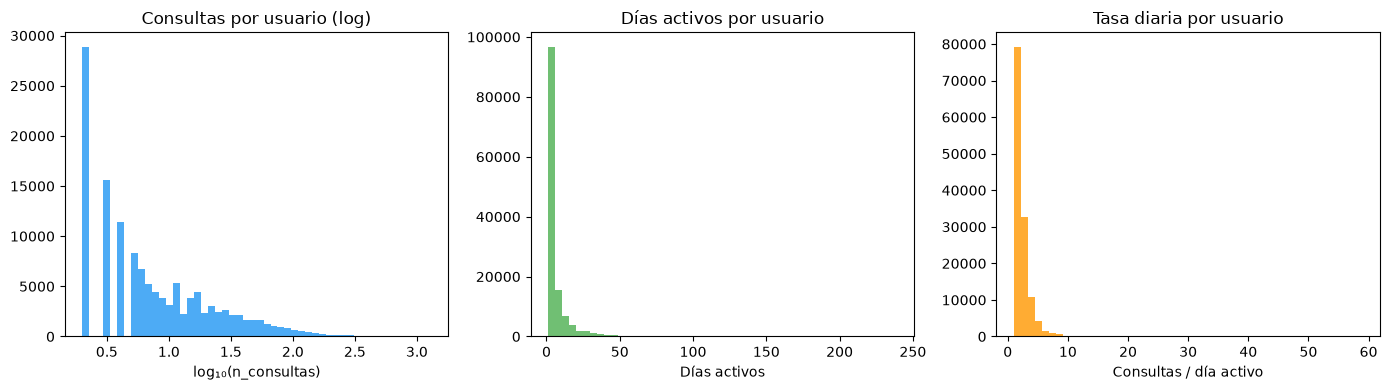


Veredicto userID:
  Mediana de consultas por usuario: 5.0
  % con ≥2 consultas: 77.9%
  → INSTALACIÓN PERSISTENTE (no efímero por sesión)


In [38]:
# Gráficos de distribución userID
fig, ejes = plt.subplots(1, 3, figsize=(14, 4))

# Log-log: consultas por usuario
n_consul = stats_usuario["n_consultas"].to_numpy()
ejes[0].hist(np.log10(n_consul[n_consul > 0] + 1), bins=50, color="#2196F3", alpha=0.8)
ejes[0].set_xlabel("log₁₀(n_consultas)"); ejes[0].set_title("Consultas por usuario (log)")

# Días activos
if "dias_activos" in stats_usuario.columns:
    ejes[1].hist(stats_usuario["dias_activos"].to_numpy(), bins=50, color="#4CAF50", alpha=0.8)
    ejes[1].set_xlabel("Días activos"); ejes[1].set_title("Días activos por usuario")

# Tasa diaria
if "tasa_diaria" in stats_usuario.columns:
    tasa = stats_usuario["tasa_diaria"].to_numpy()
    tasa = tasa[np.isfinite(tasa)]
    ejes[2].hist(np.clip(tasa, 0, 100), bins=50, color="#FF9800", alpha=0.8)
    ejes[2].set_xlabel("Consultas / día activo"); ejes[2].set_title("Tasa diaria por usuario")

plt.tight_layout()
guardar_figura(fig, "usuario_distribuciones")
plt.show()

# Veredicto
mediana_consultas = float(np.median(n_consul))
pct_mas_de_2 = (n_consul >= 2).mean() * 100
print(f"\nVeredicto userID:")
print(f"  Mediana de consultas por usuario: {mediana_consultas:.1f}")
print(f"  % con ≥2 consultas: {pct_mas_de_2:.1f}%")
if mediana_consultas >= 3 and pct_mas_de_2 >= 50:
    print("  → INSTALACIÓN PERSISTENTE (no efímero por sesión)")
elif mediana_consultas <= 2 and pct_mas_de_2 < 40:
    print("  → IDENTIFICADOR DE SESIÓN (efímero)")
else:
    print("  → MIXTO — requiere más análisis")


## §11 · Proporciones estratificadas

In [39]:
# 11.1 Perfil de municipios
if "origin_municipio" in df.columns:
    # Detectar variantes ortográficas
    munip_vals = df["origin_municipio"].drop_nulls().unique().to_list()
    print(f"Valores únicos en origin_municipio: {len(munip_vals)}")
    print(sorted(munip_vals))

    perfil_munic = (df.group_by("origin_municipio")
                    .agg([pl.len().alias("n"),
                          (pl.len() / len(df) * 100).alias("pct")])
                    .sort("n", descending=True))
    perfil_munic.write_csv(REPORTE / "perfil_municipios.csv")
    print("\nPerfil municipios origen (top 10):")
    print(perfil_munic.head(10))


Valores únicos en origin_municipio: 47
['Aiquile', 'Alalay', 'Arani', 'Arbieto', 'Bolivar', 'Capinota', 'ChimorÃ©', 'Cliza', 'Cochabamba', 'Colcapirhua', 'Colomi', 'Entre RÃ\xados', 'Mizque', 'Morochata', 'Pocona', 'Pojo', 'Puerto Villarroel', 'Quillacollo', 'Sacaba', 'Sacabamba', 'Shinahota', 'Sicaya', 'Sipesipe', 'Tacachi', 'Tacopaya', 'TapacarÃ\xad', 'Tapacarí', 'Tarata', 'Tiquipaya', 'Tiraque', 'Toco', 'Tolata', 'Totora', 'Vacas', 'Vila Vila', 'Villa Gualberto Villarroel', 'Villa JosÃ© QuintÃ\xadn Mendoza', 'Villa José Quintín Mendoza', 'Villa Punata', 'Villa Rivero', 'Villa SantivaÃ±ez', 'Villa Santivañez', 'Villa Tunari', 'Villa de Anzaldo', 'Villa de Independencia', 'Vinto', 'externo']



Perfil municipios origen (top 10):
shape: (10, 3)
┌──────────────────┬─────────┬───────────┐
│ origin_municipio ┆ n       ┆ pct       │
│ ---              ┆ ---     ┆ ---       │
│ str              ┆ u32     ┆ f64       │
╞══════════════════╪═════════╪═══════════╡
│ Cochabamba       ┆ 1661981 ┆ 86.216867 │
│ Sacaba           ┆ 92192   ┆ 4.782549  │
│ Quillacollo      ┆ 64300   ┆ 3.335625  │
│ Colcapirhua      ┆ 55338   ┆ 2.870712  │
│ Tiquipaya        ┆ 45294   ┆ 2.34967   │
│ Vinto            ┆ 3550    ┆ 0.18416   │
│ Sipesipe         ┆ 1510    ┆ 0.078333  │
│ Arbieto          ┆ 588     ┆ 0.030503  │
│ Villa Punata     ┆ 539     ┆ 0.027961  │
│ Cliza            ┆ 408     ┆ 0.021165  │
└──────────────────┴─────────┴───────────┘


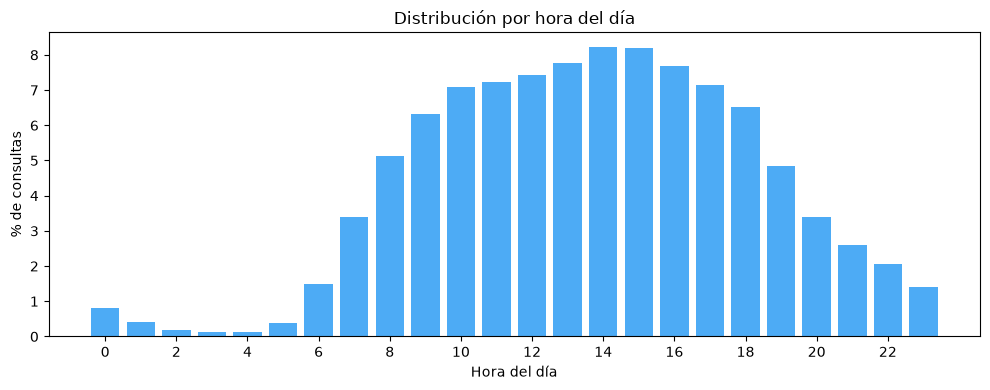

Hora pico: 14h (8.2%)


In [40]:
# 11.2 Distribución por hora del día (sin estrato source_batch — ver D-012)
if "hour" in df.columns:
    prop_hora = (df.filter(pl.col("hour").is_not_null())
                 .group_by("hour")
                 .agg(pl.len().alias("n"))
                 .with_columns((pl.col("n") / pl.col("n").sum() * 100).alias("pct"))
                 .sort("hour"))
    prop_hora.write_csv(REPORTE / "proporciones_hora.csv")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(prop_hora["hour"].to_list(), prop_hora["pct"].to_numpy(), color="#2196F3", alpha=0.8)
    ax.set_xlabel("Hora del día"); ax.set_ylabel("% de consultas")
    ax.set_title("Distribución por hora del día")
    ax.set_xticks(range(0, 24, 2))
    plt.tight_layout()
    guardar_figura(fig, "proporciones_hora")
    plt.show()
    hora_pico = prop_hora.filter(pl.col("pct") == prop_hora["pct"].max())["hour"].item()
    print(f"Hora pico: {hora_pico}h ({prop_hora.filter(pl.col('hour')==hora_pico)['pct'].item():.1f}%)")

In [41]:
# 11.3 Proporciones generales: día de semana, fin de semana, zona
proporciones: dict[str, pl.DataFrame] = {}

if "day_of_week" in df.columns:
    proporciones["dia_semana"] = (df.filter(pl.col("day_of_week").is_not_null())
                                   .group_by("day_of_week")
                                   .agg(pl.len().alias("n")).sort("day_of_week"))

if "weekend" in df.columns:
    proporciones["fin_de_semana"] = (df.filter(pl.col("weekend").is_not_null())
                                      .group_by("weekend")
                                      .agg(pl.len().alias("n")))

proporciones["zona"] = pl.DataFrame([
    {"zona": "dentro_area_gtfs",
     "n": int(df["flag_dentro_area_gtfs"].sum()) if "flag_dentro_area_gtfs" in df.columns else 0},
    {"zona": "fuera_area_gtfs_valida",
     "n": int((~df["flag_dentro_area_gtfs"] & ~df["flag_coord_cero"] & ~df["flag_coord_imposible"]).sum()) if "flag_dentro_area_gtfs" in df.columns else 0},
    {"zona": "coord_imposible",
     "n": int(df["flag_coord_imposible"].sum())},
    {"zona": "coord_cero",
     "n": int(df["flag_coord_cero"].sum())},
])

for nombre_prop, df_prop in proporciones.items():
    df_prop.write_csv(REPORTE / f"proporciones_{nombre_prop}.csv")
    print(f"--- {nombre_prop} ---")
    print(df_prop)


--- dia_semana ---
shape: (7, 2)
┌─────────────┬────────┐
│ day_of_week ┆ n      │
│ ---         ┆ ---    │
│ i64         ┆ u32    │
╞═════════════╪════════╡
│ 0           ┆ 276262 │
│ 1           ┆ 283312 │
│ 2           ┆ 302546 │
│ 3           ┆ 300656 │
│ 4           ┆ 325603 │
│ 5           ┆ 275211 │
│ 6           ┆ 164085 │
└─────────────┴────────┘
--- fin_de_semana ---
shape: (2, 2)
┌─────────┬─────────┐
│ weekend ┆ n       │
│ ---     ┆ ---     │
│ i64     ┆ u32     │
╞═════════╪═════════╡
│ 1       ┆ 439296  │
│ 0       ┆ 1488379 │
└─────────┴─────────┘
--- zona ---
shape: (4, 2)
┌────────────────────────┬─────────┐
│ zona                   ┆ n       │
│ ---                    ┆ ---     │
│ str                    ┆ i64     │
╞════════════════════════╪═════════╡
│ dentro_area_gtfs       ┆ 1925012 │
│ fuera_area_gtfs_valida ┆ 2651    │
│ coord_imposible        ┆ 9       │
│ coord_cero             ┆ 3       │
└────────────────────────┴─────────┘


## §12 · Celdas H3, sesgo y Moran's I

In [42]:
import h3 as _h3
from shapely.geometry import Polygon, Point

def _h3_safe(lat, lon, res=H3_RESOLUTION_DEFAULT):
    """Devuelve celda H3 o None si la coordenada es cero o está fuera de Bolivia."""
    if lat is None or lon is None or lat == 0.0 or lon == 0.0:
        return None
    if not (BBOX_BOLIVIA["lat_min"] <= lat <= BBOX_BOLIVIA["lat_max"]
            and BBOX_BOLIVIA["lon_min"] <= lon <= BBOX_BOLIVIA["lon_max"]):
        return None
    return _h3.latlng_to_cell(lat, lon, res)

# A3: h3_orig y h3_dest como columnas de df (null en coord cero/imposible — las filas se conservan)
df = df.with_columns([
    pl.struct(["lat_orig","lon_orig"])
      .map_elements(lambda r: _h3_safe(r["lat_orig"], r["lon_orig"]),
                    return_dtype=pl.Utf8)
      .alias("h3_orig"),
    pl.struct(["lat_dest","lon_dest"])
      .map_elements(lambda r: _h3_safe(r["lat_dest"], r["lon_dest"]),
                    return_dtype=pl.Utf8)
      .alias("h3_dest"),
])

print(f"Celdas H3 origen no nulas:  {df['h3_orig'].is_not_null().sum():,} / {df.height:,}")
print(f"Celdas H3 destino no nulas: {df['h3_dest'].is_not_null().sum():,} / {df.height:,}")

# Agregación por celda
h3_orig_agg = (
    df.filter(pl.col("h3_orig").is_not_null())
      .group_by("h3_orig")
      .agg([pl.len().alias("n_consultas"),
            pl.col("userID").n_unique().alias("n_usuarios"),
            pl.col("distancia").median().alias("distancia_mediana_m")])
      .sort("n_consultas", descending=True)
)
h3_dest_agg = (
    df.filter(pl.col("h3_dest").is_not_null())
      .group_by("h3_dest")
      .agg([pl.len().alias("n_consultas"),
            pl.col("userID").n_unique().alias("n_usuarios")])
      .sort("n_consultas", descending=True)
)

# Celdas dentro del área GTFS (para Moran y mapas)
celdas_en_area = [c for c in h3_orig_agg["h3_orig"].to_list()
                   if c is not None and AREA_GTFS.contains(
                       Point(*reversed(_h3.cell_to_latlng(c))))]

# A4: parquets de la unidad de investigación (rutas en trufi_ds.config).
# Se reescriben en §14 (dist_parada_min_m) y §15 (poblacion).
h3_orig_agg.write_parquet(H3_ORIG_PARQUET)
h3_dest_agg.write_parquet(H3_DEST_PARQUET)
print(f"\nEscrito: {H3_ORIG_PARQUET} ({h3_orig_agg.height:,} celdas)")
print(f"Escrito: {H3_DEST_PARQUET} ({h3_dest_agg.height:,} celdas)")
print(f"Celdas dentro del área GTFS: {len(celdas_en_area):,}")

Celdas H3 origen no nulas:  1,927,663 / 1,927,675
Celdas H3 destino no nulas: 1,927,672 / 1,927,675



Escrito: /home/robvox/Desktop/trufi-data-science/data/interim/h3_orig.parquet (1,516 celdas)
Escrito: /home/robvox/Desktop/trufi-data-science/data/interim/h3_dest.parquet (1,838 celdas)
Celdas dentro del área GTFS: 950


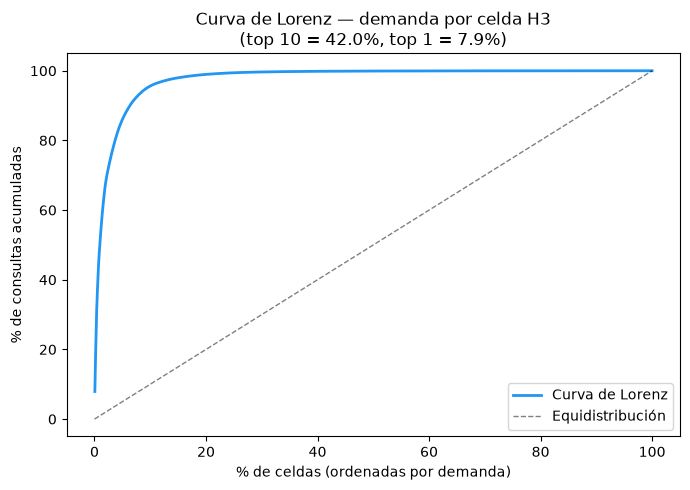

Top 10 celdas concentran 42.0% de la demanda de origen


In [43]:
# Concentración: % de consultas en top-N celdas (Lorenz)
n_cons_ord = np.sort(h3_orig_agg["n_consultas"].to_numpy())[::-1]
total_cons = n_cons_ord.sum()
lorenz_x = np.arange(1, len(n_cons_ord) + 1) / len(n_cons_ord)
lorenz_y = np.cumsum(n_cons_ord) / total_cons

top10_pct = float(np.sum(n_cons_ord[:10]) / total_cons * 100)
top1_pct = float(n_cons_ord[0] / total_cons * 100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lorenz_x * 100, lorenz_y * 100, color="#2196F3", lw=2, label="Curva de Lorenz")
ax.plot([0, 100], [0, 100], "k--", lw=1, alpha=0.5, label="Equidistribución")
ax.set_xlabel("% de celdas (ordenadas por demanda)"); ax.set_ylabel("% de consultas acumuladas")
ax.set_title(f"Curva de Lorenz — demanda por celda H3\n(top 10 = {top10_pct:.1f}%, top 1 = {top1_pct:.1f}%)")
ax.legend(); plt.tight_layout()
guardar_figura(fig, "lorenz_demanda_celdas")
plt.show()
print(f"Top 10 celdas concentran {top10_pct:.1f}% de la demanda de origen")


=== Moran's I — área GTFS Cochabamba ===
  I  = 0.7102
  EI = -0.0011
  p-valor (simulación) = 0.0010
  Celdas analizadas = 950
  → Autocorrelación SIGNIFICATIVA: validación cruzada del modelo DEBE ser espacial



  Hot spots (HH, p<0.05): 52
  Cold spots (LL, p<0.05): 327


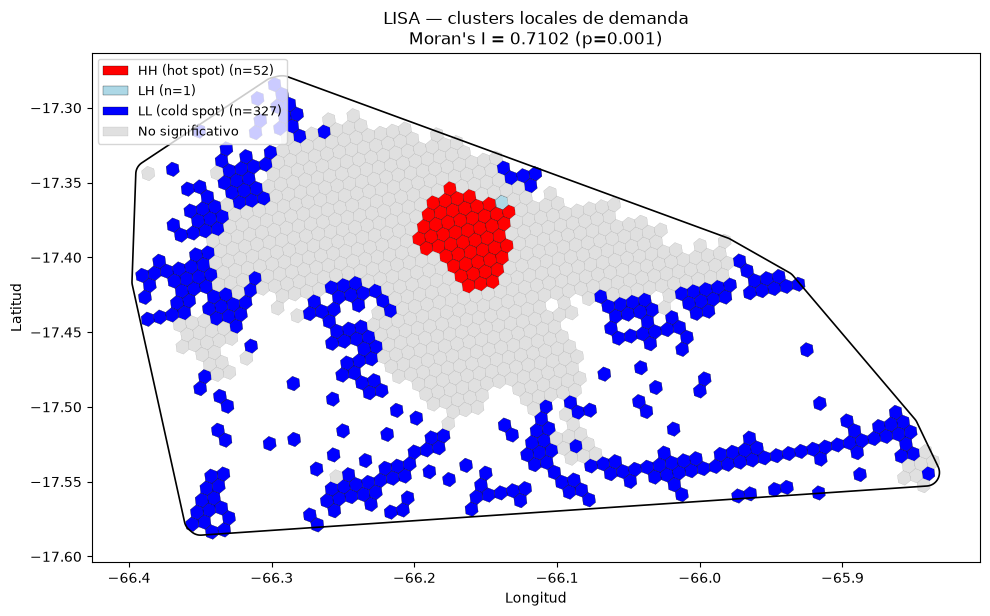

In [44]:
# B4 · Moran's I — autocorrelación espacial intraurbana (área GTFS)
# Se calcula solo sobre celdas dentro del área GTFS, no todas las de Bolivia.
# KNN sobre celdas distantes entre ciudades produce I dominado por separación
# interurbana, no por patrones intraurbanos. Ver D-011 en DECISIONES.md.
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local

df_area = h3_orig_agg.filter(pl.col("h3_orig").is_in(celdas_en_area))

if len(df_area) >= 10:
    geometrias_m = [Polygon([(lon, lat) for lat, lon in _h3.cell_to_boundary(c)])
                    for c in df_area["h3_orig"].to_list()]
    gdf_area = gpd.GeoDataFrame(df_area.to_pandas(), geometry=geometrias_m, crs="EPSG:4326")

    w = KNN.from_dataframe(gdf_area, k=6)
    w.transform = "r"
    moran = Moran(gdf_area["n_consultas"].values, w)

    print("=== Moran's I — área GTFS Cochabamba ===")
    print(f"  I  = {moran.I:.4f}")
    print(f"  EI = {moran.EI:.4f}")
    print(f"  p-valor (simulación) = {moran.p_sim:.4f}")
    print(f"  Celdas analizadas = {len(gdf_area):,}")
    if moran.p_sim < 0.05:
        print("  → Autocorrelación SIGNIFICATIVA: validación cruzada del modelo DEBE ser espacial")

    # LISA — clusters locales
    lisa = Moran_Local(gdf_area["n_consultas"].values, w)
    gdf_area = gdf_area.copy()
    gdf_area["lisa_q"] = lisa.q
    gdf_area["lisa_p"] = lisa.p_sim
    gdf_area["lisa_sig"] = lisa.p_sim < 0.05

    n_hs = int(((gdf_area["lisa_q"] == 1) & gdf_area["lisa_sig"]).sum())
    n_cs = int(((gdf_area["lisa_q"] == 3) & gdf_area["lisa_sig"]).sum())
    print(f"\n  Hot spots (HH, p<0.05): {n_hs}")
    print(f"  Cold spots (LL, p<0.05): {n_cs}")

    # Una fila por ciudad: el feed GTFS disponible cubre solo Cochabamba.
    # Si se agregan feeds de otras ciudades, añadir una fila por área GTFS.
    pl.DataFrame([{
        "ciudad": "Cochabamba (área GTFS)", "n_celdas": len(gdf_area), "k_vecinos": 6,
        "moran_I": round(moran.I, 6), "EI": round(moran.EI, 6), "p_sim": moran.p_sim,
        "n_hot_spots_HH": n_hs, "n_cold_spots_LL": n_cs,
    }]).write_csv(REPORTE / "moran_i_por_ciudad.csv")

    # Mapa LISA
    fig, ax = plt.subplots(figsize=(10, 8))
    colores_lisa = {1: "red", 2: "lightblue", 3: "blue", 4: "orange"}
    etiq_lisa = {1: "HH (hot spot)", 2: "LH", 3: "LL (cold spot)", 4: "HL"}
    for q, color in colores_lisa.items():
        sub = gdf_area[(gdf_area["lisa_q"] == q) & gdf_area["lisa_sig"]]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="black", linewidth=0.2,
                     label=f"{etiq_lisa[q]} (n={len(sub)})")
    no_sig = gdf_area[~gdf_area["lisa_sig"]]
    if len(no_sig) > 0:
        no_sig.plot(ax=ax, color="#E0E0E0", edgecolor="gray", linewidth=0.1, label="No significativo")
    gpd.GeoSeries([AREA_GTFS], crs="EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=1.2)
    ax.set_title(f"LISA — clusters locales de demanda\nMoran's I = {moran.I:.4f} (p={moran.p_sim:.3f})")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    guardar_figura(fig, "lisa_clusters_demanda")
    plt.show()
else:
    print(f"Insuficientes celdas en el área GTFS ({len(df_area)}) para Moran's I")

## §13 · Diccionario de datos

In [45]:
# Construir diccionario de datos automáticamente + descripción manual
DESCRIPCIONES = {
    "userID":            "Identificador único de instalación de la app",
    "lat_orig":          "Latitud del punto de origen de la consulta",
    "lon_orig":          "Longitud del punto de origen de la consulta",
    "lat_dest":          "Latitud del punto de destino de la consulta",
    "lon_dest":          "Longitud del punto de destino de la consulta",
    "origin_municipio":  "Municipio donde se realizó la consulta (origen)",
    "dest_municipio":    "Municipio de destino de la consulta",
    "distancia":         "Distancia geodésica haversine entre origen y destino (metros)",
    "hour":              "Hora local del día (0–23) en que se realizó la consulta",
    "day_of_week":       "Día de la semana (0=lunes en Python, verificar por lote)",
    "day_of_month":      "Día del mes (1–31)",
    "weekend":           "1 si es fin de semana, 0 si es día hábil",
    "year":              "Año ISO de la semana de la consulta",
    "week":              "Número de semana ISO (1–53)",
    "ts":                "Marca de tiempo de la consulta (parseada de 'date')",
    "year_week_number":  "Número de semana del año — SOLO en lote_2024_nuevo (100% nulo en lote_original)",
    "time_of_day":       "Categoría textual de la hora — SOLO en lote_2024_nuevo",
    "source_file":       "Nombre del archivo CSV de origen (linaje)",
    "source_batch":      "Lote de exportación: lote_original | lote_2024_nuevo",
    "source_encoding":   "Codificación detectada: utf-8 | latin-1",
}

FUENTES = {col: "85 CSV Trufi App" for col in DESCRIPCIONES}
FUENTES.update({"source_file": "Derivada", "source_batch": "Derivada", "source_encoding": "Derivada",
                "year": "Derivada", "week": "Derivada", "ts": "Derivada"})

dict_datos = []
for col in df.columns:
    n_nulos = df[col].is_null().sum()
    serie = df[col]
    tipo_polars = str(serie.dtype)
    val_min = val_max = rango = "n/a"
    try:
        if serie.dtype in (pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt32, pl.Float32, pl.Float64):
            vals_no_nulos = serie.drop_nulls()
            if len(vals_no_nulos) > 0:
                val_min = str(round(float(vals_no_nulos.min()), 4))
                val_max = str(round(float(vals_no_nulos.max()), 4))
                rango = f"{val_min} – {val_max}"
    except Exception:
        pass
    dict_datos.append({
        "columna":     col,
        "tipo_polars": tipo_polars,
        "n_nulos":     n_nulos,
        "pct_nulos":   round(n_nulos / len(df) * 100, 3),
        "rango":       rango,
        "descripcion": DESCRIPCIONES.get(col, ""),
        "fuente":      FUENTES.get(col, ""),
    })

df_diccionario = pl.DataFrame(dict_datos)
df_diccionario.write_csv(REPORTE / "diccionario_datos.csv")
print(df_diccionario.select(["columna","tipo_polars","pct_nulos","descripcion"]))


shape: (26, 4)
┌───────────────────────┬─────────────┬───────────┬─────────────────────────────────┐
│ columna               ┆ tipo_polars ┆ pct_nulos ┆ descripcion                     │
│ ---                   ┆ ---         ┆ ---       ┆ ---                             │
│ str                   ┆ str         ┆ f64       ┆ str                             │
╞═══════════════════════╪═════════════╪═══════════╪═════════════════════════════════╡
│ date                  ┆ String      ┆ 0.0       ┆                                 │
│ lat_orig              ┆ Float64     ┆ 0.0       ┆ Latitud del punto de origen de… │
│ lon_orig              ┆ Float64     ┆ 0.0       ┆ Longitud del punto de origen d… │
│ lat_dest              ┆ Float64     ┆ 0.0       ┆ Latitud del punto de destino d… │
│ lon_dest              ┆ Float64     ┆ 0.0       ┆ Longitud del punto de destino … │
│ …                     ┆ …           ┆ …         ┆ …                               │
│ flag_coord_cero       ┆ Boolean     ┆

## §14 · Comprensión del feed GTFS

In [46]:
# Leer archivos GTFS
import pandas as pdp

gtfs_archivos = {
    "agency":     GTFS_DIR / "agency.txt",
    "stops":      GTFS_DIR / "stops.txt",
    "routes":     GTFS_DIR / "routes.txt",
    "trips":      GTFS_DIR / "trips.txt",
    "stop_times": GTFS_DIR / "stop_times.txt",
    "shapes":     GTFS_DIR / "shapes.txt",
    "calendar":   GTFS_DIR / "calendar.txt",
}

gtfs = {}
for nombre, ruta in gtfs_archivos.items():
    if ruta.exists():
        gtfs[nombre] = pdp.read_csv(ruta)
        print(f"{nombre:<12}: {len(gtfs[nombre]):>8,} filas  | cols: {list(gtfs[nombre].columns)}")
    else:
        print(f"{nombre:<12}: no encontrado en {ruta}")


agency      :       43 filas  | cols: ['agency_id', 'agency_name', 'agency_timezone', 'agency_url']
stops       :   22,320 filas  | cols: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'stop_desc']
routes      :      141 filas  | cols: ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_color', 'route_type']
trips       :      626 filas  | cols: ['trip_id', 'route_id', 'service_id', 'shape_id', 'trip_headsign', 'direction_id']


stop_times  :   99,161 filas  | cols: ['trip_id', 'stop_sequence', 'stop_id', 'arrival_time', 'departure_time', 'timepoint']


shapes      :  343,381 filas  | cols: ['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence']
calendar    :        2 filas  | cols: ['service_id', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'start_date', 'end_date']


In [47]:
# Estadísticas básicas del feed
if "stops" in gtfs:
    stops = gtfs["stops"]
    print(f"Paradas totales: {len(stops):,}")
    print(f"  Con lat/lon válidos: {stops['stop_lat'].notna().sum():,}")
    lat_range = f"{stops['stop_lat'].min():.4f} – {stops['stop_lat'].max():.4f}"
    lon_range = f"{stops['stop_lon'].min():.4f} – {stops['stop_lon'].max():.4f}"
    print(f"  Rango latitud:  {lat_range}")
    print(f"  Rango longitud: {lon_range}")

if "routes" in gtfs:
    print(f"\nRutas: {len(gtfs['routes']):,}")
    if "route_type" in gtfs["routes"].columns:
        print(gtfs["routes"]["route_type"].value_counts())

if "shapes" in gtfs:
    print(f"\nFormas (shapes): {gtfs['shapes']['shape_id'].nunique():,} shape_ids")
    print(f"Puntos de forma: {len(gtfs['shapes']):,}")


Paradas totales: 22,320
  Con lat/lon válidos: 22,320
  Rango latitud:  -17.5767 – -17.2876
  Rango longitud: -66.3885 – -65.8414

Rutas: 141
route_type
3    137
0      3
6      1
Name: count, dtype: int64

Formas (shapes): 626 shape_ids
Puntos de forma: 343,381


In [48]:
# Paradas → celdas H3 (previsualización de cobertura)
if "stops" in gtfs:
    stops_validas = gtfs["stops"].dropna(subset=["stop_lat","stop_lon"]).copy()
    stops_validas["h3_celda"] = stops_validas.apply(
        lambda r: _h3.latlng_to_cell(r["stop_lat"], r["stop_lon"], H3_RESOLUTION_DEFAULT), axis=1
    )
    n_celdas_con_parada = stops_validas["h3_celda"].nunique()
    print(f"Celdas H3 r{H3_RESOLUTION_DEFAULT} con al menos una parada GTFS: {n_celdas_con_parada:,}")

    # ¿Cuántas celdas de consulta tienen cobertura GTFS?
    if len(h3_orig_agg) > 0:
        celdas_consulta = set(h3_orig_agg["h3_orig"].to_list())
        celdas_parada = set(stops_validas["h3_celda"].to_list())
        solapamiento = celdas_consulta & celdas_parada
        print(f"Celdas de consulta:          {len(celdas_consulta):,}")
        pct_celdas_con_parada = len(solapamiento) / len(celdas_consulta) * 100
        print(f"Celdas de consulta con GTFS: {len(solapamiento):,} ({pct_celdas_con_parada:.1f}%)")

Celdas H3 r8 con al menos una parada GTFS: 638
Celdas de consulta:          1,516
Celdas de consulta con GTFS: 608 (40.1%)


In [49]:
# C3 · Distancia mínima de cada celda de consulta a la parada GTFS más cercana
# Métrica de gradiente de cobertura para el OE1 (no binario tiene/no-tiene parada)
if "stops" in gtfs and len(h3_orig_agg) > 0:
    from scipy.spatial import cKDTree

    # Paradas válidas proyectadas a UTM 19S
    stops_gdf_utm = gpd.GeoDataFrame(
        stops_validas,
        geometry=gpd.points_from_xy(stops_validas["stop_lon"], stops_validas["stop_lat"]),
        crs="EPSG:4326"
    ).to_crs("EPSG:32719")
    coords_stops_utm = np.column_stack([stops_gdf_utm.geometry.x, stops_gdf_utm.geometry.y])
    tree_stops = cKDTree(coords_stops_utm)

    # Centroides de celdas H3 → UTM
    centros_h3 = [_h3.cell_to_latlng(c) for c in h3_orig_agg["h3_orig"].to_list()]
    centros_gdf = gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lat, lon in centros_h3],
        crs="EPSG:4326"
    ).to_crs("EPSG:32719")
    coords_h3_utm = np.column_stack([centros_gdf.geometry.x, centros_gdf.geometry.y])

    dist_parada_m, _ = tree_stops.query(coords_h3_utm, k=1)

    h3_orig_agg = h3_orig_agg.with_columns(
        pl.Series("dist_parada_min_m", dist_parada_m)
    )
    h3_orig_agg.write_parquet(H3_ORIG_PARQUET)  # actualizar parquet con nueva columna

    dist_parada_mediana_m = float(np.median(dist_parada_m))
    print(f"Distancia mediana celda→parada: {dist_parada_mediana_m:.0f} m")
    print(f"Distancia media:                {np.mean(dist_parada_m):.0f} m")
    n_leq500 = int((dist_parada_m <= 500).sum())
    n_gt500  = int((dist_parada_m > 500).sum())
    pct500   = n_leq500 / len(dist_parada_m) * 100
    print(f"Celdas a ≤ 500 m de parada: {n_leq500:,} ({pct500:.1f}%)")
    print(f"Celdas a > 500 m de parada: {n_gt500:,}  ({100-pct500:.1f}%)")

Distancia mediana celda→parada: 879 m
Distancia media:                26735 m
Celdas a ≤ 500 m de parada: 610 (40.2%)
Celdas a > 500 m de parada: 906  (59.8%)


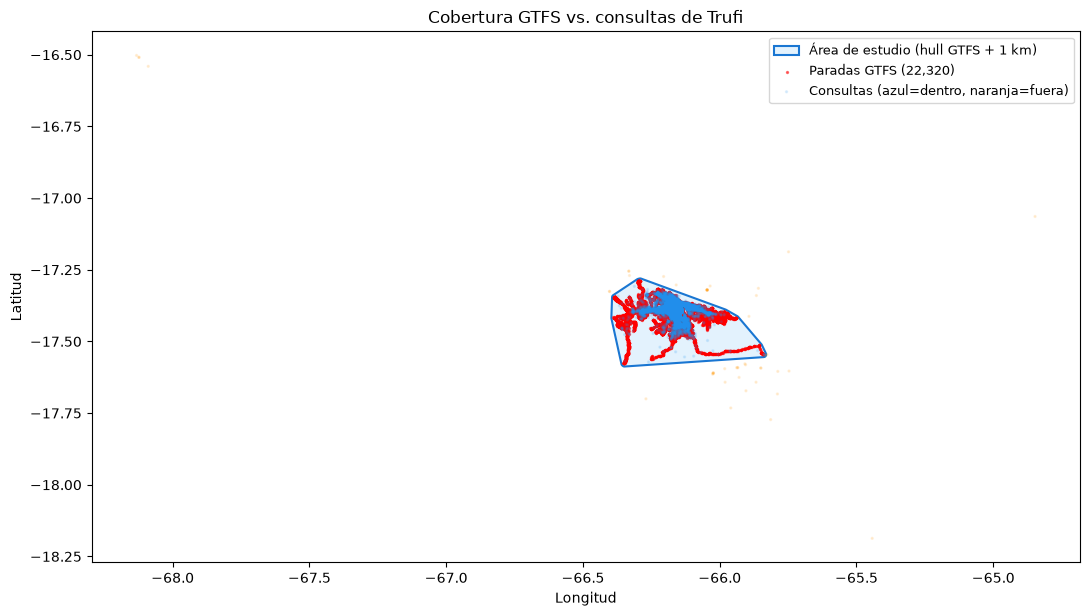


Consultas dentro del área GTFS: 1,925,012 / 1,927,675 (99.9%)


In [50]:
# B3 · Mapa invertido: GTFS como marco, consultas encima — orden visual = orden lógico del OE1
if "stops" in gtfs:
    fig, ax = plt.subplots(figsize=(11, 9))

    # Capa 1 (fondo): área de estudio GTFS
    gpd.GeoSeries([AREA_GTFS], crs="EPSG:4326").plot(
        ax=ax, color="#E3F2FD", edgecolor="#1976D2", linewidth=1.5,
        label="Área de estudio (hull GTFS + 1 km)"
    )

    # Capa 2: paradas GTFS
    stops_validas_gdf = gpd.GeoDataFrame(
        stops_validas,
        geometry=gpd.points_from_xy(stops_validas["stop_lon"], stops_validas["stop_lat"]),
        crs="EPSG:4326"
    )
    stops_validas_gdf.plot(ax=ax, color="red", markersize=2, alpha=0.5,
                            label=f"Paradas GTFS ({len(stops_validas):,})")

    # Capa 3: consultas (azul=dentro área GTFS, naranja=fuera)
    if "flag_dentro_area_gtfs" in df.columns:
        df_validas = df.filter(~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible"))
        muestra = df_validas.sample(min(30_000, df_validas.height), seed=42).to_pandas()
        colores_pts = ["#2196F3" if v else "#FF9800" for v in muestra["flag_dentro_area_gtfs"]]
        ax.scatter(muestra["lon_orig"], muestra["lat_orig"],
                   c=colores_pts, s=2, alpha=0.12,
                   label="Consultas (azul=dentro, naranja=fuera)")

    ax.set_title("Cobertura GTFS vs. consultas de Trufi")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    guardar_figura(fig, "cobertura_gtfs_vs_consultas")
    plt.show()

    # C1 · Métrica central del OE1
    if "flag_dentro_area_gtfs" in df.columns:
        n_dentro = int(df["flag_dentro_area_gtfs"].sum())
        n_total  = df.height
        print(f"\nConsultas dentro del área GTFS: {n_dentro:,} / {n_total:,} ({n_dentro/n_total*100:.1f}%)")

## §15 · Comprensión de datos Kontur Population

In [51]:
import gzip

# Leer Kontur 2023 y 2022
kontur_2023_path = DATA_EXTERNAL / "kontur_population_BO_20231101.gpkg.gz"
kontur_2022_path = DATA_EXTERNAL / "kontur_population_BO_20220630.gpkg.gz"

for nombre_kontur, ruta_kontur in [("Kontur 2023", kontur_2023_path), ("Kontur 2022", kontur_2022_path)]:
    if not ruta_kontur.exists():
        print(f"{nombre_kontur}: no encontrado en {ruta_kontur}")
        continue

    import tempfile, shutil
    with tempfile.NamedTemporaryFile(suffix=".gpkg", delete=False) as tmp:
        tmp_path = Path(tmp.name)
    with gzip.open(ruta_kontur, "rb") as f_in:
        with open(tmp_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    kontur_gdf = gpd.read_file(tmp_path)
    tmp_path.unlink()

    print(f"\n=== {nombre_kontur} ===")
    print(f"  Filas: {len(kontur_gdf):,}")
    print(f"  Columnas: {list(kontur_gdf.columns)}")
    print(f"  CRS original: {kontur_gdf.crs}")
    print(f"  Población total Bolivia: {kontur_gdf['population'].sum():,.0f}")

    # A1: reproyectar a EPSG:4326 si viene en EPSG:3857
    if kontur_gdf.crs != "EPSG:4326":
        kontur_gdf = kontur_gdf.to_crs("EPSG:4326")
        print(f"  CRS corregido: {kontur_gdf.crs}")
        print(f"  Bounds (grados): {kontur_gdf.total_bounds}")

    if nombre_kontur == "Kontur 2023":
        kontur_2023 = kontur_gdf
    else:
        kontur_2022 = kontur_gdf



=== Kontur 2023 ===
  Filas: 145,929
  Columnas: ['h3', 'population', 'geometry']
  CRS original: EPSG:3857
  Población total Bolivia: 12,431,735


  CRS corregido: EPSG:4326
  Bounds (grados): [-69.62456895 -22.89801599 -57.49935588  -9.6675403 ]



=== Kontur 2022 ===
  Filas: 178,201
  Columnas: ['h3', 'population', 'geometry']
  CRS original: EPSG:3857
  Población total Bolivia: 9,995,771


  CRS corregido: EPSG:4326
  Bounds (grados): [-69.62456867 -22.89322931 -57.49935572  -9.66754023]


In [52]:
# A2 · Integración Kontur ↔ consultas por ID H3 (no por geometría/bbox) — ver D-010
# Kontur trae columna 'h3' → join directo, robusto al CRS del .gpkg.
import shapely

assert "h3" in kontur_2023.columns, "Kontur 2023 sin columna h3"
res_kontur = {_h3.get_resolution(c) for c in kontur_2023["h3"].head(100)}
print(f"Resoluciones H3 en Kontur: {res_kontur}")
assert res_kontur == {H3_RESOLUTION_DEFAULT}, "Resolución Kontur ≠ H3_RESOLUTION_DEFAULT: el join por ID no aplica"

# A1 · Verificación obligatoria: población Kontur dentro del área GTFS
_latlon_k = np.array([_h3.cell_to_latlng(c) for c in kontur_2023["h3"]])
kontur_2023["en_area_gtfs"] = shapely.contains_xy(AREA_GTFS, _latlon_k[:, 1], _latlon_k[:, 0])
pob_area_gtfs = float(kontur_2023.loc[kontur_2023["en_area_gtfs"], "population"].sum())
print(f"Población Kontur 2023 en el área GTFS: {pob_area_gtfs:,.0f} "
      f"({int(kontur_2023['en_area_gtfs'].sum()):,} celdas)")
if not 1.0e6 <= pob_area_gtfs <= 2.5e6:
    print("  ⚠ Fuera del orden de magnitud esperado (~1–2 M, eje metropolitano) — revisar CRS/área")

kontur_pl = (
    pl.from_pandas(kontur_2023[["h3", "population"]])
      .rename({"h3": "h3_cell", "population": "poblacion"})
      .with_columns(pl.col("poblacion").cast(pl.Int64))
)

# Población por celda de origen y de destino → columnas de df
pob_origen = (df.select("h3_orig").unique().drop_nulls()
              .join(kontur_pl, left_on="h3_orig", right_on="h3_cell", how="left")
              .select("h3_orig", pl.col("poblacion").fill_null(0).alias("poblacion_orig")))
pob_dest = (df.select("h3_dest").unique().drop_nulls()
            .join(kontur_pl, left_on="h3_dest", right_on="h3_cell", how="left")
            .select("h3_dest", pl.col("poblacion").fill_null(0).alias("poblacion_dest")))
df = (df.drop([c for c in ("poblacion_orig", "poblacion_dest") if c in df.columns])
        .join(pob_origen, on="h3_orig", how="left")
        .join(pob_dest, on="h3_dest", how="left"))

# Población por celda → parquets de la unidad de investigación
def _con_poblacion(agg: pl.DataFrame, col_h3: str) -> pl.DataFrame:
    return (agg.drop([c for c in ("poblacion",) if c in agg.columns])
               .join(kontur_pl, left_on=col_h3, right_on="h3_cell", how="left")
               .with_columns(pl.col("poblacion").fill_null(0)))

h3_orig_agg = _con_poblacion(h3_orig_agg, "h3_orig")
h3_dest_agg = _con_poblacion(h3_dest_agg, "h3_dest")
h3_orig_agg.write_parquet(H3_ORIG_PARQUET)
h3_dest_agg.write_parquet(H3_DEST_PARQUET)

n_con_pob = int((h3_orig_agg["poblacion"] > 0).sum())
print(f"\nCeldas de origen con población > 0: {n_con_pob:,} / {h3_orig_agg.height:,}")
print(f"Consultas con origen en celda poblada: {int((df['poblacion_orig'] > 0).sum()):,} / {df.height:,}")
print(f"Población total en celdas de origen:   {int(h3_orig_agg['poblacion'].sum()):,}")
print(f"Reescritos: {H3_ORIG_PARQUET.name}, {H3_DEST_PARQUET.name} (columna 'poblacion')")

# Tabla de población por celda de consulta para notebooks posteriores
h3_orig_agg.select("h3_orig", "poblacion").write_parquet(POBLACION_KONTUR_2023_H3R8)
print(f"Guardado: {POBLACION_KONTUR_2023_H3R8}")

# Celdas Kontur del área de estudio (para el mapa)
kontur_cbba = kontur_2023[kontur_2023["en_area_gtfs"]].copy()
kontur_cbba["lat"] = _latlon_k[kontur_2023["en_area_gtfs"].to_numpy(), 0]
kontur_cbba["lon"] = _latlon_k[kontur_2023["en_area_gtfs"].to_numpy(), 1]

Resoluciones H3 en Kontur: {8}


Población Kontur 2023 en el área GTFS: 1,184,713 (1,393 celdas)



Celdas de origen con población > 0: 1,412 / 1,516
Consultas con origen en celda poblada: 1,927,330 / 1,927,675
Población total en celdas de origen:   1,697,447
Reescritos: h3_orig.parquet, h3_dest.parquet (columna 'poblacion')
Guardado: /home/robvox/Desktop/trufi-data-science/data/interim/poblacion_kontur_2023_h3r8.parquet


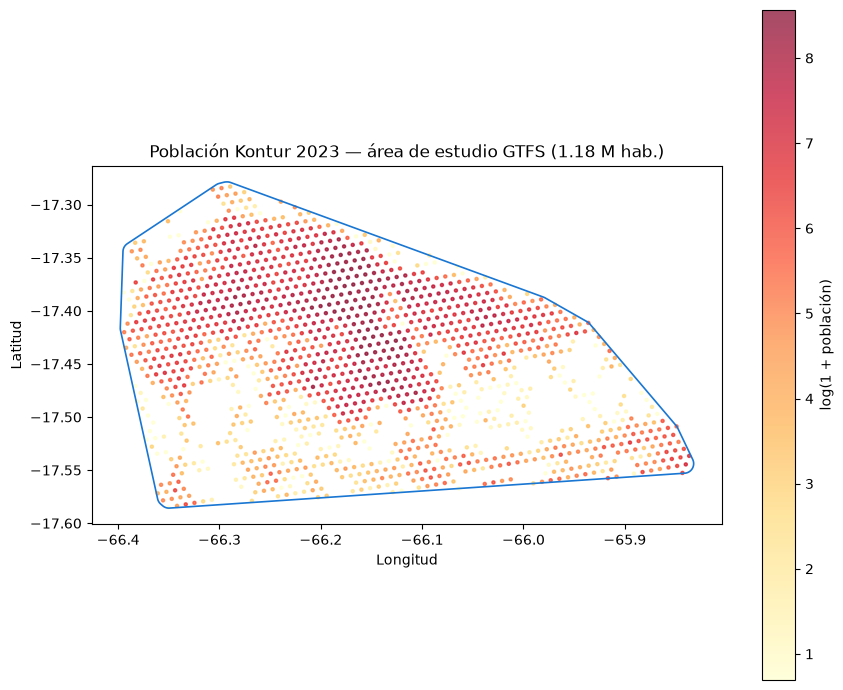

In [53]:
# Mapa de población Kontur en el área de estudio GTFS
if "kontur_cbba" in dir() and len(kontur_cbba) > 0:
    fig, ax = plt.subplots(figsize=(9, 7))
    kontur_cbba_sorted = kontur_cbba.sort_values("population", ascending=True)
    gpd.GeoSeries([AREA_GTFS], crs="EPSG:4326").boundary.plot(ax=ax, color="#1976D2", linewidth=1.2)
    sc = ax.scatter(
        kontur_cbba_sorted["lon"], kontur_cbba_sorted["lat"],
        c=np.log1p(kontur_cbba_sorted["population"]),
        cmap="YlOrRd", s=5, alpha=0.7
    )
    plt.colorbar(sc, ax=ax, label="log(1 + población)")
    ax.set_title(f"Población Kontur 2023 — área de estudio GTFS ({pob_area_gtfs/1e6:.2f} M hab.)")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    plt.tight_layout()
    guardar_figura(fig, "kontur_poblacion_metro")
    plt.show()

## §16 · Resumen final y decisiones

In [54]:
# Hallazgos cuantitativos para el resumen
hallazgos = {
    "total_filas": df.height,
    "total_archivos_csv": len(archivos_csv),
    "grupos_esquema": len(grupos_esquema),
    "archivos_latin1": sum(1 for r in reporte_codif if r["codificacion"]=="latin-1"),
    "filas_coord_cero": int(df["flag_coord_cero"].sum()),
    "filas_coord_imposible": int(df["flag_coord_imposible"].sum()),
    "filas_dentro_gtfs": int(df["flag_dentro_area_gtfs"].sum()) if "flag_dentro_area_gtfs" in df.columns else 0,
    "filas_fuera_gtfs": int((~df["flag_dentro_area_gtfs"] & ~df["flag_coord_cero"] & ~df["flag_coord_imposible"]).sum()) if "flag_dentro_area_gtfs" in df.columns else 0,
    "semanas_faltantes": len(semanas_faltantes),
    "celdas_h3_origen": h3_orig_agg.height,
    "celdas_h3_destino": h3_dest_agg.height,
    "top10_celdas_pct_demanda": round(top10_pct, 1),
}

if "exacto" in [r.get("definicion","") for r in resumen_dups]:
    hallazgos["duplicados_exactos"] = next(r["n_duplicados"] for r in resumen_dups if r.get("definicion")=="exacto")

if "flag_dentro_area_gtfs" in df.columns:
    pct_dentro = hallazgos["filas_dentro_gtfs"] / hallazgos["total_filas"] * 100
    hallazgos["pct_dentro_area_gtfs"] = round(pct_dentro, 1)

# Métricas centrales del OE1 (cobertura)
if "pct_celdas_con_parada" in dir():
    hallazgos["pct_celdas_consulta_con_parada"] = round(pct_celdas_con_parada, 1)
if "dist_parada_mediana_m" in dir():
    hallazgos["dist_mediana_celda_parada_m"] = round(dist_parada_mediana_m)
if "pob_area_gtfs" in dir():
    hallazgos["poblacion_kontur_area_gtfs"] = int(pob_area_gtfs)
if "moran" in dir():
    hallazgos["moran_I_cochabamba"] = round(float(moran.I), 4)
    hallazgos["moran_p_sim"] = round(float(moran.p_sim), 4)

# C1 · titular del OE1
print(f"COBERTURA: {hallazgos.get('pct_dentro_area_gtfs', 'N/A')}% de las consultas "
      f"tiene origen dentro del área GTFS\n")

print("=== RESUMEN CUANTITATIVO ===")
for k, v in hallazgos.items():
    print(f"  {k:<45} {v:>10,}" if isinstance(v, int) else f"  {k:<45} {v}")

COBERTURA: 99.9% de las consultas tiene origen dentro del área GTFS

=== RESUMEN CUANTITATIVO ===
  total_filas                                    1,927,675
  total_archivos_csv                                    85
  grupos_esquema                                         2
  archivos_latin1                                        6
  filas_coord_cero                                       3
  filas_coord_imposible                                  9
  filas_dentro_gtfs                              1,925,012
  filas_fuera_gtfs                                   2,651
  semanas_faltantes                                      7
  celdas_h3_origen                                   1,516
  celdas_h3_destino                                  1,838
  top10_celdas_pct_demanda                      42.0
  duplicados_exactos                                   104
  pct_dentro_area_gtfs                          99.9
  pct_celdas_consulta_con_parada                40.1
  dist_mediana_celda_parada_m      

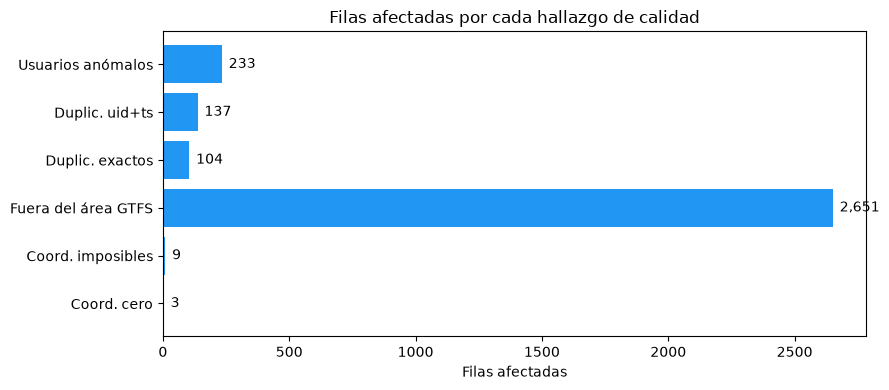

In [55]:
# Gráfico de barras: filas afectadas por cada hallazgo de calidad
categorias_calidad = {
    "Coord. cero":       int(df["flag_coord_cero"].sum()),
    "Coord. imposibles": int(df["flag_coord_imposible"].sum()),
    "Fuera del área GTFS": int((~df["flag_dentro_area_gtfs"] & ~df["flag_coord_cero"] & ~df["flag_coord_imposible"]).sum()) if "flag_dentro_area_gtfs" in df.columns else 0,
}
if "exacto" in indices_dups:
    categorias_calidad["Duplic. exactos"] = int(indices_dups["exacto"].sum())
if "uid_ts" in indices_dups:
    categorias_calidad["Duplic. uid+ts"] = int(indices_dups["uid_ts"].sum())
if "flag_anomalo" in stats_usuario.columns:
    n_filas_anomalos = int(
        df.join(
            stats_usuario.filter(pl.col("flag_anomalo")).select("userID"),
            on="userID", how="inner"
        ).height
    )
    categorias_calidad["Usuarios anómalos"] = n_filas_anomalos

fig, ax = plt.subplots(figsize=(9, 4))
etiq_cal = list(categorias_calidad.keys())
vals_cal = list(categorias_calidad.values())
barras = ax.barh(etiq_cal, vals_cal, color="#2196F3")
ax.bar_label(barras, fmt="{:,.0f}", padding=5)
ax.set_xlabel("Filas afectadas")
ax.set_title("Filas afectadas por cada hallazgo de calidad")
plt.tight_layout()
guardar_figura(fig, "hallazgos_calidad_resumen")
plt.show()


### Decisiones de la Etapa 1

Las decisiones D-001 a D-012 se redactan y mantienen **a mano** en `DECISIONES.md`, no desde este notebook. Antes, estas celdas agregaban texto al archivo en modo *append* con una guarda de texto; se reemplazaron por una verificación de solo lectura para que re-ejecutar el notebook nunca modifique ni duplique la bitácora.

In [ ]:
# Verificación de solo lectura: la bitácora contiene las decisiones de la Etapa 1
import re
_texto_dec = (RAIZ / "DECISIONES.md").read_text(encoding="utf-8")
_ids = sorted(set(re.findall(r"^### (D-0(?:0[1-9]|1[0-2])) ", _texto_dec, flags=re.M)))
assert _ids == [f"D-{i:03d}" for i in range(1, 13)], f"Faltan decisiones de la Etapa 1: {_ids}"
print(f"DECISIONES.md contiene D-001 a D-012 ({len(_ids)} decisiones); este notebook no lo modifica.")

In [58]:
# Regenerar reports/01_data_understanding/README.md
resumen_md = f"""# Reporte — Comprensión de datos (§7.2)

Generado por: `notebooks/01_comprension_datos.ipynb`

> **Cobertura (OE1): {hallazgos.get('pct_dentro_area_gtfs', 'N/A')}% de las consultas tiene origen
> dentro del área de estudio GTFS** (convex hull de paradas + shapes, buffer 1 km — D-009).

## Hallazgos cuantitativos

| Métrica | Valor |
|---|---|
| Consultas consolidadas | {hallazgos['total_filas']:,} |
| Archivos CSV | {hallazgos['total_archivos_csv']} |
| Grupos de esquema | {hallazgos['grupos_esquema']} |
| Archivos con Latin-1 | {hallazgos['archivos_latin1']} |
| Coordenadas (0,0) | {hallazgos['filas_coord_cero']:,} |
| Coordenadas imposibles | {hallazgos['filas_coord_imposible']:,} |
| Consultas dentro del área GTFS | {hallazgos.get('filas_dentro_gtfs', 'N/A'):,} ({hallazgos.get('pct_dentro_area_gtfs', 'N/A')}%) |
| Celdas de consulta con ≥1 parada GTFS | {hallazgos.get('pct_celdas_consulta_con_parada', 'N/A')}% |
| Distancia mediana celda → parada | {hallazgos.get('dist_mediana_celda_parada_m', 'N/A')} m |
| Población Kontur 2023 en área GTFS | {hallazgos.get('poblacion_kontur_area_gtfs', 'N/A'):,} |
| Moran's I (Cochabamba, KNN k=6) | {hallazgos.get('moran_I_cochabamba', 'N/A')} (p={hallazgos.get('moran_p_sim', 'N/A')}) |
| Semanas sin datos | {hallazgos['semanas_faltantes']} |
| Celdas H3 de origen | {hallazgos['celdas_h3_origen']:,} |
| Top-10 celdas = % demanda | {hallazgos['top10_celdas_pct_demanda']}% |

## Artefactos generados

- `schema_diff.csv`, `grupos_esquema.json`
- `reporte_codificacion.csv`, `cobertura_columnas_por_lote.csv`
- `nulos_globales.csv`, `nulos_por_archivo.csv`, `nulos_por_mes.csv`, `nulos_correlacion.csv`
- `duplicados_resumen.csv`, `duplicados_solapamiento.csv`, `duplicados_impacto_celdas.csv`
- `coordenadas_cero.csv`, `coordenadas_imposibles.csv`, `coordenadas_fuera_area_gtfs.csv`, `area_estudio_gtfs.geojson`
- `distancia_verificacion_unidad.csv`, `distancia_percentiles.csv`, `distancia_sobre_umbral.csv`, `distancia_outliers_iqr.csv`
- `semanas_faltantes.csv`, `cobertura_mensual.csv`, `cobertura_temporal_celda.csv`
- `estadisticas_usuario.csv`, `usuarios_anomalos.csv`
- `perfil_municipios.csv`, `proporciones_hora.csv`, `proporciones_zona.csv`
- `moran_i_por_ciudad.csv`
- `diccionario_datos.csv`
- `figuras/` — gráficos del EDA

## Decisiones registradas

Ver `DECISIONES.md` §Etapa 1, D-001 a D-012.
"""

(REPORTE / "README.md").write_text(resumen_md, encoding="utf-8")
print("README.md generado")
print("\n✅ EDA completo finalizado. Ver DECISIONES.md para las acciones de la Etapa de Preparación.")

README.md generado

✅ EDA completo finalizado. Ver DECISIONES.md para las acciones de la Etapa de Preparación.
